# Data Preparation / Feature Engineering

## Business objective and success criteria
This project aims to predict Remaining Useful Life (RUL) for aircraft engines so maintenance can be scheduled before failures occur. In practice, the model should help reduce unplanned downtime, avoid costly emergency repairs, and support proactive maintenance planning.

A good model should:
- predict RUL early enough to allow action before failure,
- keep prediction errors low enough that maintenance decisions are reliable,
- and generalize well to unseen engines rather than only memorizing the training set.

For this notebook, we use RMSE, MAE, and R² on a held-out validation set as the primary success criteria. Lower RMSE/MAE and higher R² indicate better predictive performance.


In the previous step1_eda.ipynb, we have performed some statistical analysis and draw insights on how to prepare our preliminary dataset. Including:

Train/Val split:
1. Splits dataset into training and validation before standardization, standardization should fit on train set only.
2. Must maintain local chronological order for each engine.

Data cleaning:
1. Compute life_ratio as labels
2. Removing the columns: settings1, settings2, settings3, engine_id (drop when training), T2, P2, farB, NF_dmd, PCNfR_dmd, and Nrc

Feature Scaling:
1. Sensor features are standardized using statistics computed exclusively from the training set.
2. The same transformation is applied to validation data to ensure consistency and prevent data leakage.

Feature Engineering: 
1. Compute rolling window statistics feature for sensors, grouped by engine_id.
2. Compute lags of current timestep.

In [1]:
import pandas as pd
import sys
sys.path.append("..")
from src.const import SENSOR_NAMES

columns = ['engine_id', 'cycle'] + SENSOR_NAMES

df = pd.read_csv("../data/raw/train_FD001.txt", sep=r'\s+', header=None,
                       usecols=range(len(columns)), names=columns, engine='python')

### Train/Val split

In [2]:
from sklearn.model_selection import train_test_split
# -----------------------------
# 1. Train/Validation split by engine_id
# -----------------------------
engine_ids = df["engine_id"].unique()

train_ids, val_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["engine_id"].isin(train_ids)].copy()
val_df   = df[df["engine_id"].isin(val_ids)].copy()

# -----------------------------
# 2. Maintain local chronological order per engine
# -----------------------------
train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
val_df   = val_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

# -----------------------------
# 3. Sanity checks
# -----------------------------
assert set(train_df["engine_id"]).isdisjoint(set(val_df["engine_id"])), "Leakage detected!"
assert train_df["cycle"].is_monotonic_increasing is False or True  # per-engine ordering enforced

print("Train engines:", train_df["engine_id"].nunique())
print("Val engines:", val_df["engine_id"].nunique())
print("Split complete without engine leakage.")

Train engines: 80
Val engines: 20
Split complete without engine leakage.


In [3]:
train_df

,engine_id,cycle,T2,T24,T30,T50,P2,P15,P30,Nf,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,9054.72,1.3,46.93,522.33,2388.06,8137.72,8.3905,0.03,391,2388
1,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,9051.31,1.3,47.24,522.70,2387.98,8131.09,8.4167,0.03,392,2388
2,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,9054.24,1.3,47.22,522.58,2387.99,8140.58,8.3802,0.03,391,2388
3,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,...,9058.01,1.3,47.10,522.49,2387.93,8140.44,8.4018,0.03,391,2388
4,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,...,9058.15,1.3,47.25,522.27,2387.94,8136.67,8.3867,0.03,390,2388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388
16557,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388
16558,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388
16559,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388


In [4]:
val_df

,engine_id,cycle,T2,T24,T30,T50,P2,P15,P30,Nf,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0010,-0.0000,100.0,518.67,642.98,1600.49,1427.11,14.62,...,9045.20,1.3,48.24,519.76,2388.28,8119.61,8.5282,0.03,395,2388
4066,91,132,-0.0025,-0.0003,100.0,518.67,643.91,1596.94,1428.41,14.62,...,9041.93,1.3,48.02,519.76,2388.30,8120.68,8.5323,0.03,397,2388
4067,91,133,0.0012,-0.0001,100.0,518.67,644.22,1602.83,1426.55,14.62,...,9049.93,1.3,48.07,519.35,2388.26,8120.11,8.5183,0.03,396,2388
4068,91,134,0.0004,0.0006,100.0,518.67,643.70,1606.40,1430.92,14.62,...,9052.04,1.3,48.20,519.43,2388.33,8119.01,8.5215,0.03,396,2388


In [5]:
train_df.nunique()

engine_id      80
cycle         362
T2            156
T24            13
T30             1
T50             1
P2            305
P15          2878
P30          3893
Nf              1
Nc              2
epr           501
Ps30           53
phi          5911
NRf             1
NRc           155
BPR           425
farB           55
htBleed      5652
Nf_dmd       1871
PCNfR_dmd       1
W31            13
W32             1
dtype: int64

In [6]:
val_df.nunique()

engine_id      20
cycle         269
T2            133
T24            13
T30             1
T50             1
P2            276
P15          1976
P30          2409
Nf              1
Nc              2
epr           454
Ps30           43
phi          2729
NRf             1
NRc           144
BPR           366
farB           45
htBleed      2678
Nf_dmd       1410
PCNfR_dmd       1
W31            11
W32             1
dtype: int64

### Preprocess

In [7]:
# -----------------------------
# 1. Compute life_ratio
# -----------------------------
def add_rul(df, engine_col="engine_id", cycle_col="cycle"):
    """
    Adds a Remaining Useful Life (RUL) column to a CMAPSS dataframe.

    RUL = max_cycle - current_cycle, computed independently for each engine.
    """
    df = df.copy()

    df["max_cycle"] = df.groupby(engine_col)[cycle_col].transform("max")
    df["RUL"] = df["max_cycle"] - df[cycle_col]

    df.drop(columns=["max_cycle"], inplace=True)

    return df

def add_life_ratio(df, engine_col="engine_id", cycle_col="cycle", rul_col="RUL"):
    """
    Adds a normalized life_ratio column to a CMAPSS dataframe.

    life_ratio = RUL / max_cycle, always in [0, 1]. It represents the
    fraction of remaining life: close to 1 early in an engine's life and
    0 at the failure cycle. Requires RUL to already be present.
    """
    df = df.copy()

    max_cycle = df.groupby(engine_col)[cycle_col].transform("max")
    df["life_ratio"] = df[rul_col] / max_cycle

    return df

# -----------------------------
# 2. Drop unwanted columns
# -----------------------------
def clean_features(df, cols_to_drop=[]):
    df = df.copy()
    # drop feature columns
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

# -----------------------------
# 3. Full preprocessing pipeline
# -----------------------------
def preprocess(df, cols_to_drop=[]):
    df = add_rul(df)
    df = add_life_ratio(df)
    # RUL is dropped so it can't leak into the features; life_ratio is the target now
    df = df.drop(columns=["RUL"])
    df = clean_features(df, cols_to_drop)
    return df

In [8]:
cols_to_drop = [
    "setting_1", "setting_2", "setting_3",
    "T2", "P2", "farB", "Nf_dmd", "PCNfR_dmd", "Nc",
    "P15", "P30", "epr"
]
# cols_to_drop = []
train_df = preprocess(train_df, cols_to_drop=cols_to_drop)
val_df   = preprocess(val_df, cols_to_drop=cols_to_drop)

In [9]:
train_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,2,1,0.0006,100.0,518.67,14.62,2388.01,9054.72,1.3,46.93,522.33,8137.72,391,2388,0.996516
1,2,2,-0.0003,100.0,518.67,14.62,2387.98,9051.31,1.3,47.24,522.70,8131.09,392,2388,0.993031
2,2,3,0.0003,100.0,518.67,14.62,2388.04,9054.24,1.3,47.22,522.58,8140.58,391,2388,0.989547
3,2,4,-0.0004,100.0,518.67,14.62,2387.98,9058.01,1.3,47.10,522.49,8140.44,391,2388,0.986063
4,2,5,0.0004,100.0,518.67,14.62,2388.03,9058.15,1.3,47.25,522.27,8136.67,390,2388,0.982578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0003,100.0,518.67,14.62,2388.19,9065.52,1.3,48.07,519.49,8137.60,397,2388,0.020000
16557,100,197,-0.0005,100.0,518.67,14.62,2388.23,9065.11,1.3,48.04,519.68,8136.50,395,2388,0.015000
16558,100,198,0.0000,100.0,518.67,14.62,2388.24,9065.90,1.3,48.09,520.01,8141.05,398,2388,0.010000
16559,100,199,0.0003,100.0,518.67,14.62,2388.25,9073.72,1.3,48.39,519.67,8139.29,395,2388,0.005000


In [10]:
val_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,1,1,-0.0004,100.0,518.67,14.62,2388.06,9046.19,1.3,47.47,521.66,8138.62,392,2388,0.994792
1,1,2,-0.0003,100.0,518.67,14.62,2388.04,9044.07,1.3,47.49,522.28,8131.49,392,2388,0.989583
2,1,3,0.0003,100.0,518.67,14.62,2388.08,9052.94,1.3,47.27,522.42,8133.23,390,2388,0.984375
3,1,4,0.0000,100.0,518.67,14.62,2388.11,9049.48,1.3,47.13,522.86,8133.83,392,2388,0.979167
4,1,5,-0.0002,100.0,518.67,14.62,2388.06,9055.15,1.3,47.28,522.19,8133.80,393,2388,0.973958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0000,100.0,518.67,14.62,2388.26,9045.20,1.3,48.24,519.76,8119.61,395,2388,0.029630
4066,91,132,-0.0003,100.0,518.67,14.62,2388.30,9041.93,1.3,48.02,519.76,8120.68,397,2388,0.022222
4067,91,133,-0.0001,100.0,518.67,14.62,2388.29,9049.93,1.3,48.07,519.35,8120.11,396,2388,0.014815
4068,91,134,0.0006,100.0,518.67,14.62,2388.27,9052.04,1.3,48.20,519.43,8119.01,396,2388,0.007407


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Define sensor columns
# -----------------------------
def get_sensor_columns(df):
    return df.select_dtypes(include=["float64", "int64"]).columns.drop(
        ["life_ratio", "cycle", "engine_id"], errors="ignore"
    )

sensor_cols = get_sensor_columns(train_df)

# -----------------------------
# 2. Fit scaler ONLY on training set
# -----------------------------
scaler = StandardScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()

scaler.fit(train_df_scaled[sensor_cols])

train_df_scaled[sensor_cols] = scaler.transform(train_df_scaled[sensor_cols])
val_df_scaled[sensor_cols] = scaler.transform(val_df_scaled[sensor_cols])

# -----------------------------
# 3. Sanity check
# -----------------------------
print("Scaling complete.")
print("Train shape:", train_df_scaled.shape)
print("Val shape:", val_df_scaled.shape)

Scaling complete.
Train shape: (16561, 15)
Val shape: (4070, 15)


In [12]:
train_df_scaled

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,2,1,2.043793,0.0,0.0,-5.329071e-15,-1.221017,-0.471297,-2.220446e-16,-2.294365,1.242127,-0.315944,-1.426246,0.0,0.996516
1,2,2,-1.031739,0.0,0.0,-5.329071e-15,-1.645675,-0.621789,-2.220446e-16,-1.127747,1.745551,-0.654442,-0.779529,0.0,0.993031
2,2,3,1.018616,0.0,0.0,-5.329071e-15,-0.796358,-0.492481,-2.220446e-16,-1.203012,1.582278,-0.169925,-1.426246,0.0,0.989547
3,2,4,-1.373465,0.0,0.0,-5.329071e-15,-1.645675,-0.326102,-2.220446e-16,-1.654606,1.459824,-0.177072,-1.426246,0.0,0.986063
4,2,5,1.360341,0.0,0.0,-5.329071e-15,-0.937911,-0.319923,-2.220446e-16,-1.090114,1.160491,-0.369552,-2.072963,0.0,0.982578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-1.031739,0.0,0.0,-5.329071e-15,1.326935,0.005332,-2.220446e-16,1.995779,-2.621987,-0.322070,2.454058,0.0,0.020000
16557,100,197,-1.715191,0.0,0.0,-5.329071e-15,1.893147,-0.012762,-2.220446e-16,1.882880,-2.363472,-0.378231,1.160624,0.0,0.015000
16558,100,198,-0.006562,0.0,0.0,-5.329071e-15,2.034700,0.022102,-2.220446e-16,2.071044,-1.914473,-0.145928,3.100776,0.0,0.010000
16559,100,199,1.018616,0.0,0.0,-5.329071e-15,2.176253,0.367217,-2.220446e-16,3.200030,-2.377078,-0.235786,1.160624,0.0,0.005000


In [13]:
train_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
count,16561.000000,16561.000000,1.656100e+04,16561.0,16561.0,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,16561.0,16561.000000
mean,53.022704,109.377815,-2.231038e-17,0.0,0.0,-5.329071e-15,-1.117482e-12,1.123757e-14,-2.220446e-16,-3.514743e-15,1.054938e-13,3.933492e-15,-1.643417e-14,0.0,0.497585
std,29.258544,69.639875,1.000030e+00,0.0,0.0,0.000000e+00,1.000030e+00,1.000030e+00,0.000000e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,0.0,0.288681
min,2.000000,1.000000,-2.056917e+00,0.0,0.0,-5.329071e-15,-2.778098e+00,-1.927223e+00,-2.220446e-16,-2.595427e+00,-3.710470e+00,-2.244824e+00,-3.366398e+00,0.0,0.000000
25%,27.000000,52.000000,-6.900133e-01,0.0,0.0,-5.329071e-15,-6.548050e-01,-5.410265e-01,-2.220446e-16,-7.137854e-01,-6.218996e-01,-5.313983e-01,-7.795285e-01,0.0,0.247525
50%,55.000000,104.000000,-6.561730e-03,0.0,0.0,-5.329071e-15,-8.859342e-02,-1.981182e-01,-2.220446e-16,-1.116601e-01,9.922029e-02,-1.592030e-01,-1.328112e-01,0.0,0.497512
75%,79.000000,157.000000,1.018616e+00,0.0,0.0,-5.329071e-15,6.191710e-01,1.761241e-01,-2.220446e-16,6.033638e-01,7.250979e-01,2.232035e-01,5.139062e-01,0.0,0.747525
max,100.000000,362.000000,2.043793e+00,0.0,0.0,-5.329071e-15,6.564392e+00,7.908111e+00,-2.220446e-16,3.689256e+00,2.670761e+00,7.648730e+00,4.394210e+00,0.0,0.997238


In [14]:
val_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
count,4070.000000,4070.000000,4070.000000,4070.0,4070.0,4.070000e+03,4070.000000,4070.000000,4.070000e+03,4070.000000,4070.000000,4070.000000,4070.000000,4070.0,4070.000000
mean,45.337346,106.488698,0.007460,0.0,0.0,-5.329071e-15,0.028196,-0.034953,-2.220446e-16,0.028562,-0.024872,-0.040245,0.017348,0.0,0.497543
std,28.278657,65.659973,1.007403,0.0,0.0,0.000000e+00,1.023892,0.862803,0.000000e+00,1.025404,1.017466,0.859039,1.008026,0.0,0.288707
min,1.000000,1.000000,-2.056917,0.0,0.0,-5.329071e-15,-2.494992,-1.420143,-2.220446e-16,-2.407263,-3.207046,-1.683723,-2.719681,0.0,0.000000
25%,19.000000,51.000000,-1.031739,0.0,0.0,-5.329071e-15,-0.796358,-0.546764,-2.220446e-16,-0.751418,-0.676324,-0.584879,-0.779529,0.0,0.246874
50%,45.000000,102.000000,-0.006562,0.0,0.0,-5.329071e-15,0.052959,-0.256814,-2.220446e-16,-0.036394,0.031190,-0.215364,-0.132811,0.0,0.497636
75%,77.000000,154.000000,1.018616,0.0,0.0,-5.329071e-15,0.760724,0.185723,-2.220446e-16,0.678629,0.738704,0.230224,0.513906,0.0,0.747179
max,91.000000,269.000000,2.043793,0.0,0.0,-5.329071e-15,3.450229,4.442398,-2.220446e-16,3.726889,2.303398,4.438354,3.747493,0.0,0.996283


### Feature Engineering (Adding rolling window and lags):
- Useful for Tree models

In [15]:
import numpy as np

WINDOW = 5
LAGS = [1, 2]

def add_time_series_features(df, sensor_cols):
    df = df.copy()
    df = df.sort_values(["engine_id", "cycle"])

    group_cols = ["engine_id"]

    # -------------------------
    # Rolling mean features
    # -------------------------
    for col in sensor_cols:
        df[f"{col}_roll_mean"] = (
            df.groupby(group_cols)[col]
              .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
        )

    # -------------------------
    # Lag features
    # -------------------------
    for col in sensor_cols:
        for lag in LAGS:
            df[f"{col}_lag{lag}"] = (
                df.groupby(group_cols)[col]
                  .shift(lag)
            )

    return df

In [16]:
def fit_feature_selector(train_df, target="life_ratio", top_k=10):
    # keep ONLY numeric columns
    numeric_df = train_df.select_dtypes(include=["number"]).copy()

    feature_cols = numeric_df.columns.drop([target], errors="ignore")

    corr = numeric_df[feature_cols].corrwith(numeric_df[target]).abs()
    var = numeric_df[feature_cols].var()

    score = corr * var

    score_df = (
        pd.DataFrame({
            "correlation": corr,
            "variance": var,
            "score": score
        })
        .sort_values(by="score", ascending=False)
    )

    print("\n===== Feature Scores (Top 20) =====")
    print(score_df.head(20))

    # -------------------------
    # top-k logic fix
    # -------------------------
    if top_k == -1:
        top_features = score_df.index.tolist()
        print("\nSelected ALL features")
    else:
        top_features = score_df.head(top_k).index.tolist()
        print(f"\nSelected Top {top_k} Features:")

    print(top_features)

    return top_features

In [17]:
def get_sensor_columns(df):
    exclude = {"life_ratio", "cycle", "engine_id"}

    return [
        c for c in df.select_dtypes(include=["number"]).columns
        if c not in exclude
    ]

In [18]:
def apply_feature_selection(df, selected_features, target="life_ratio"):
    if "cycle" not in selected_features:
        selected_features.append("cycle")
    if "engine_id" not in selected_features:
        selected_features.append("engine_id")
    keep_cols = [target] + selected_features
    return df[keep_cols].copy()

In [19]:
def feature_engineering_pipeline(train_df, val_df, top_k=10):
    # -------------------------
    # 1. sensor columns from TRAIN ONLY
    # -------------------------
    sensor_cols = get_sensor_columns(train_df)

    # -------------------------
    # 2. Feature engineering
    # -------------------------
    train_fe = add_time_series_features(train_df, sensor_cols)
    val_fe   = add_time_series_features(val_df, sensor_cols)
    # train_fe = train_df
    # val_fe = val_df

    # handle NaNs from lag
    train_fe = train_fe.dropna().reset_index(drop=True)
    val_fe   = val_fe.dropna().reset_index(drop=True)

    # -------------------------
    # 3. Feature selection (TRAIN ONLY)
    # -------------------------
    selected_features = fit_feature_selector(train_fe, top_k=top_k)

    print("Top selected features:", selected_features)

    # -------------------------
    # 4. Apply selection
    # -------------------------
    train_final = apply_feature_selection(train_fe, selected_features)
    val_final   = apply_feature_selection(val_fe, selected_features)

    return train_final, val_final, selected_features

In [20]:
train_final, val_final, selected_features = feature_engineering_pipeline(
    train_df_scaled,
    val_df_scaled,
    top_k=10
)


===== Feature Scores (Top 20) =====
                correlation     variance        score
cycle              0.899545  4782.378682  4301.963637
engine_id          0.001105   856.267425     0.946241
NRc                0.732691     0.999654     0.732438
NRc_lag1           0.727760     0.975917     0.710233
BPR                0.705401     1.000597     0.705822
NRc_lag2           0.722854     0.952378     0.688430
BPR_lag1           0.699790     0.976480     0.683331
BPR_lag2           0.694276     0.955295     0.663239
NRc_roll_mean      0.771527     0.836765     0.645587
W31                0.643505     0.999805     0.643379
W31_lag1           0.636693     0.978922     0.623273
BPR_roll_mean      0.748687     0.821831     0.615295
W31_lag2           0.631028     0.962284     0.607229
Ps30               0.576890     1.000793     0.577347
Ps30_lag1          0.571022     0.975361     0.556952
Ps30_lag2          0.564577     0.954338     0.538797
W31_roll_mean      0.761281     0.662069     

/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [21]:
train_final

,life_ratio,cycle,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,BPR_lag2,NRc_roll_mean,W31
0,0.989547,3,2,-1.203012,-1.127747,1.582278,-2.294365,1.745551,1.242127,-1.541708,-1.426246
1,0.986063,4,2,-1.654606,-1.203012,1.459824,-1.127747,1.582278,1.745551,-1.569932,-1.426246
2,0.982578,5,2,-1.090114,-1.654606,1.160491,-1.203012,1.459824,1.582278,-1.473969,-2.072963
3,0.979094,6,2,-1.842771,-1.090114,1.881611,-1.654606,1.160491,1.459824,-1.383650,-0.779529
4,0.975610,7,2,-1.654606,-1.842771,0.983613,-1.090114,1.881611,1.160491,-1.489022,-1.426246
...,...,...,...,...,...,...,...,...,...,...,...
16396,0.020000,196,100,1.995779,2.560271,-2.621987,2.183943,-2.322654,-2.540351,2.319421,2.454058
16397,0.015000,197,100,1.882880,1.995779,-2.363472,2.560271,-2.621987,-2.322654,2.214049,1.160624
16398,0.010000,198,100,2.071044,1.882880,-1.914473,1.995779,-2.363472,-2.621987,2.138784,3.100776
16399,0.005000,199,100,3.200030,2.071044,-2.377078,1.882880,-1.914473,-2.363472,2.342001,1.160624


In [22]:
val_final

,life_ratio,cycle,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,BPR_lag2,NRc_roll_mean,W31
0,0.984375,3,1,-1.014848,-0.186926,1.364582,-0.262191,1.174097,0.330523,-0.487988,-2.072963
1,0.979167,4,1,-1.541708,-1.014848,1.963247,-0.186926,1.364582,1.174097,-0.751418,-0.779529
2,0.973958,5,1,-0.977215,-1.541708,1.051643,-1.014848,1.963247,1.364582,-0.796578,-0.132811
3,0.968750,6,1,-1.428809,-0.977215,0.357735,-1.541708,1.051643,1.963247,-1.029901,-1.426246
4,0.963542,7,1,-0.676153,-1.428809,1.228521,-0.977215,0.357735,1.051643,-1.127747,-0.779529
...,...,...,...,...,...,...,...,...,...,...,...
4025,0.029630,131,91,2.635537,2.372107,-2.254624,1.769982,-2.200200,-2.390684,2.409740,1.160624
4026,0.022222,132,91,1.807615,2.635537,-2.254624,2.372107,-2.254624,-2.200200,2.221576,2.454058
4027,0.014815,133,91,1.995779,1.807615,-2.812471,2.635537,-2.254624,-2.254624,2.116204,1.807341
4028,0.007407,134,91,2.485006,1.995779,-2.703623,1.807615,-2.812471,-2.254624,2.259209,1.807341


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

TARGET = "life_ratio"

X_train = train_final.drop(columns=[TARGET, "engine_id"], errors="ignore")
y_train = train_final[TARGET]

X_val = val_final.drop(columns=[TARGET, "engine_id"], errors="ignore")
y_val = val_final[TARGET]

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)

In [24]:
def evaluate(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{ name } Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.0256
MAE : 0.0185
R2  : 0.9920

Validation Performance:
RMSE: 0.0601
MAE : 0.0447
R2  : 0.9557


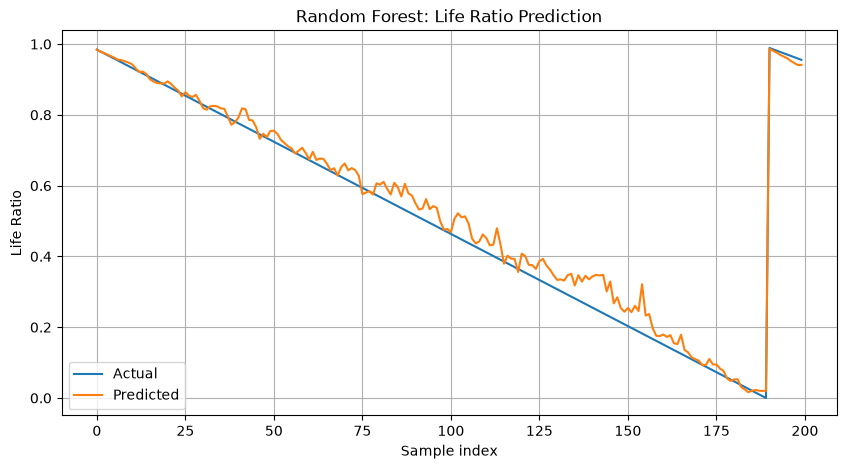

Mean validation residual (Actual - Predicted): -0.00463148424449871


In [25]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("Random Forest: Life Ratio Prediction")
plt.ylabel("Life Ratio")
plt.xlabel("Sample index")
plt.legend()
plt.grid()
plt.show()

print("Mean validation residual (Actual - Predicted):", (y_val - y_pred_val).mean())

On the validation set, the untuned Random Forest baseline has a mean residual of about -0.005 (Actual - Predicted), i.e. a very slight overprediction of life_ratio on average -- much smaller in relative terms than the ~30-cycle bias seen when RUL was the raw target.

### Hyperparameter tuning with Optuna

In [26]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# Hyperparameter tuning random forest
besr_rf = None
best_rmse = None

def rf_objective(trial):
    global besr_rf, best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5, 0.8, None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if best_rmse is None or rmse < best_rmse:
        best_rmse = rmse
        besr_rf = model

    return rmse


In [28]:
study = optuna.create_study(direction="minimize")
study.optimize(rf_objective, n_trials=100)

[I 2026-07-05 14:43:10,401] A new study created in memory with name: no-name-c2f66190-243d-412b-bd94-5791ab82f04f


[I 2026-07-05 14:43:10,860] Trial 0 finished with value: 0.05875826641061907 and parameters: {'n_estimators': 163, 'max_depth': 66, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': True}. Best is trial 0 with value: 0.05875826641061907.


[I 2026-07-05 14:43:12,260] Trial 1 finished with value: 0.05926119038609415 and parameters: {'n_estimators': 181, 'max_depth': 81, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.05875826641061907.


[I 2026-07-05 14:43:12,601] Trial 2 finished with value: 0.058643654895428374 and parameters: {'n_estimators': 183, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 2 with value: 0.058643654895428374.


[I 2026-07-05 14:43:13,874] Trial 3 finished with value: 0.08491873637398911 and parameters: {'n_estimators': 230, 'max_depth': 33, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': False}. Best is trial 2 with value: 0.058643654895428374.


[I 2026-07-05 14:43:14,717] Trial 4 finished with value: 0.05826151252774704 and parameters: {'n_estimators': 574, 'max_depth': 90, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 4 with value: 0.05826151252774704.


[I 2026-07-05 14:43:15,153] Trial 5 finished with value: 0.05841257901449151 and parameters: {'n_estimators': 218, 'max_depth': 52, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.5, 'bootstrap': True}. Best is trial 4 with value: 0.05826151252774704.


[I 2026-07-05 14:43:15,630] Trial 6 finished with value: 0.05914354222038475 and parameters: {'n_estimators': 200, 'max_depth': 81, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 0.8, 'bootstrap': True}. Best is trial 4 with value: 0.05826151252774704.


[I 2026-07-05 14:43:16,242] Trial 7 finished with value: 0.05801841995663277 and parameters: {'n_estimators': 330, 'max_depth': 95, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 0.5, 'bootstrap': True}. Best is trial 7 with value: 0.05801841995663277.


[I 2026-07-05 14:43:16,501] Trial 8 finished with value: 0.058849875411794414 and parameters: {'n_estimators': 152, 'max_depth': 11, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 7 with value: 0.05801841995663277.


[I 2026-07-05 14:43:17,102] Trial 9 finished with value: 0.05796682232672428 and parameters: {'n_estimators': 397, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 9 with value: 0.05796682232672428.


[I 2026-07-05 14:43:17,692] Trial 10 finished with value: 0.06104229819201415 and parameters: {'n_estimators': 482, 'max_depth': 8, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 9 with value: 0.05796682232672428.


[I 2026-07-05 14:43:18,357] Trial 11 finished with value: 0.058037310815523775 and parameters: {'n_estimators': 367, 'max_depth': 99, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': True}. Best is trial 9 with value: 0.05796682232672428.


[I 2026-07-05 14:43:18,968] Trial 12 finished with value: 0.05794236337272769 and parameters: {'n_estimators': 344, 'max_depth': 52, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 0.5, 'bootstrap': True}. Best is trial 12 with value: 0.05794236337272769.


[I 2026-07-05 14:43:19,509] Trial 13 finished with value: 0.05797755228740494 and parameters: {'n_estimators': 371, 'max_depth': 49, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 12 with value: 0.05794236337272769.


[I 2026-07-05 14:43:20,338] Trial 14 finished with value: 0.058661890667689835 and parameters: {'n_estimators': 442, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 12 with value: 0.05794236337272769.


[I 2026-07-05 14:43:20,881] Trial 15 finished with value: 0.057926340787992046 and parameters: {'n_estimators': 294, 'max_depth': 46, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 15 with value: 0.057926340787992046.


[I 2026-07-05 14:43:21,372] Trial 16 finished with value: 0.05780272153422201 and parameters: {'n_estimators': 293, 'max_depth': 51, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 16 with value: 0.05780272153422201.


[I 2026-07-05 14:43:21,849] Trial 17 finished with value: 0.057939456606387336 and parameters: {'n_estimators': 282, 'max_depth': 43, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 16 with value: 0.05780272153422201.


[I 2026-07-05 14:43:22,110] Trial 18 finished with value: 0.058501457986947426 and parameters: {'n_estimators': 103, 'max_depth': 65, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': False}. Best is trial 16 with value: 0.05780272153422201.


[I 2026-07-05 14:43:22,585] Trial 19 finished with value: 0.05773004372248361 and parameters: {'n_estimators': 275, 'max_depth': 69, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 19 with value: 0.05773004372248361.


[I 2026-07-05 14:43:23,082] Trial 20 finished with value: 0.05773369102340404 and parameters: {'n_estimators': 271, 'max_depth': 66, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 19 with value: 0.05773004372248361.


[I 2026-07-05 14:43:23,532] Trial 21 finished with value: 0.05772144865408858 and parameters: {'n_estimators': 268, 'max_depth': 65, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:23,957] Trial 22 finished with value: 0.05772880060969639 and parameters: {'n_estimators': 248, 'max_depth': 65, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:24,389] Trial 23 finished with value: 0.05772880060969639 and parameters: {'n_estimators': 248, 'max_depth': 74, 'min_samples_split': 9, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:24,871] Trial 24 finished with value: 0.057840427201538765 and parameters: {'n_estimators': 241, 'max_depth': 75, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:25,230] Trial 25 finished with value: 0.05932026451519949 and parameters: {'n_estimators': 118, 'max_depth': 76, 'min_samples_split': 7, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:25,708] Trial 26 finished with value: 0.058418323931235375 and parameters: {'n_estimators': 313, 'max_depth': 58, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:26,213] Trial 27 finished with value: 0.058759209313171246 and parameters: {'n_estimators': 236, 'max_depth': 59, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 0.8, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:26,870] Trial 28 finished with value: 0.05777374455379948 and parameters: {'n_estimators': 419, 'max_depth': 87, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:27,247] Trial 29 finished with value: 0.058757944887240114 and parameters: {'n_estimators': 146, 'max_depth': 72, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:27,661] Trial 30 finished with value: 0.05772880060969639 and parameters: {'n_estimators': 248, 'max_depth': 40, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:28,091] Trial 31 finished with value: 0.057723193281112306 and parameters: {'n_estimators': 254, 'max_depth': 39, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:28,439] Trial 32 finished with value: 0.05784131862258295 and parameters: {'n_estimators': 194, 'max_depth': 61, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:28,907] Trial 33 finished with value: 0.059316301424003806 and parameters: {'n_estimators': 174, 'max_depth': 81, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:29,320] Trial 34 finished with value: 0.057835698175787785 and parameters: {'n_estimators': 262, 'max_depth': 36, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:29,747] Trial 35 finished with value: 0.058339096314058765 and parameters: {'n_estimators': 215, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': False}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:30,208] Trial 36 finished with value: 0.05803066355728173 and parameters: {'n_estimators': 309, 'max_depth': 57, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:31,110] Trial 37 finished with value: 0.059441089387866686 and parameters: {'n_estimators': 340, 'max_depth': 85, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:32,015] Trial 38 finished with value: 0.05773116915419622 and parameters: {'n_estimators': 596, 'max_depth': 64, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:32,509] Trial 39 finished with value: 0.05839162174764308 and parameters: {'n_estimators': 221, 'max_depth': 76, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': False}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:32,931] Trial 40 finished with value: 0.05927628036934741 and parameters: {'n_estimators': 166, 'max_depth': 92, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 0.8, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:33,321] Trial 41 finished with value: 0.05772319127712432 and parameters: {'n_estimators': 250, 'max_depth': 43, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:33,729] Trial 42 finished with value: 0.05772597584522538 and parameters: {'n_estimators': 253, 'max_depth': 39, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:34,074] Trial 43 finished with value: 0.057810879792172414 and parameters: {'n_estimators': 200, 'max_depth': 24, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:34,611] Trial 44 finished with value: 0.0583204864219523 and parameters: {'n_estimators': 317, 'max_depth': 36, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:34,994] Trial 45 finished with value: 0.05830555814201802 and parameters: {'n_estimators': 260, 'max_depth': 42, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:35,374] Trial 46 finished with value: 0.05782744337717314 and parameters: {'n_estimators': 219, 'max_depth': 31, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:35,888] Trial 47 finished with value: 0.05819479296671717 and parameters: {'n_estimators': 360, 'max_depth': 26, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:36,694] Trial 48 finished with value: 0.05772845407454462 and parameters: {'n_estimators': 516, 'max_depth': 47, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:37,803] Trial 49 finished with value: 0.058476517581514245 and parameters: {'n_estimators': 543, 'max_depth': 37, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': False}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:39,029] Trial 50 finished with value: 0.059268855004837036 and parameters: {'n_estimators': 509, 'max_depth': 46, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:39,730] Trial 51 finished with value: 0.057729800048277914 and parameters: {'n_estimators': 450, 'max_depth': 54, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:40,348] Trial 52 finished with value: 0.05777524829813018 and parameters: {'n_estimators': 385, 'max_depth': 48, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:40,840] Trial 53 finished with value: 0.05782614855467022 and parameters: {'n_estimators': 292, 'max_depth': 54, 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:41,126] Trial 54 finished with value: 0.05780061845237686 and parameters: {'n_estimators': 149, 'max_depth': 45, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:41,486] Trial 55 finished with value: 0.05783144654826465 and parameters: {'n_estimators': 196, 'max_depth': 39, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 21 with value: 0.05772144865408858.


[I 2026-07-05 14:43:42,266] Trial 56 finished with value: 0.057660402840165964 and parameters: {'n_estimators': 489, 'max_depth': 21, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:42,997] Trial 57 finished with value: 0.05832527951889403 and parameters: {'n_estimators': 544, 'max_depth': 13, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:43,693] Trial 58 finished with value: 0.06479963981325847 and parameters: {'n_estimators': 550, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:45,746] Trial 59 finished with value: 0.05871018200548562 and parameters: {'n_estimators': 481, 'max_depth': 21, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.8, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:46,779] Trial 60 finished with value: 0.05834393155267082 and parameters: {'n_estimators': 521, 'max_depth': 33, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': False}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:47,572] Trial 61 finished with value: 0.05771225521156369 and parameters: {'n_estimators': 497, 'max_depth': 28, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:48,367] Trial 62 finished with value: 0.05772150687414516 and parameters: {'n_estimators': 489, 'max_depth': 27, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:49,077] Trial 63 finished with value: 0.057685090237364706 and parameters: {'n_estimators': 462, 'max_depth': 16, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:49,893] Trial 64 finished with value: 0.057757745582871715 and parameters: {'n_estimators': 466, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:50,616] Trial 65 finished with value: 0.05819044318839756 and parameters: {'n_estimators': 497, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:51,314] Trial 66 finished with value: 0.05769104322243354 and parameters: {'n_estimators': 431, 'max_depth': 29, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:51,998] Trial 67 finished with value: 0.05769976476866972 and parameters: {'n_estimators': 413, 'max_depth': 29, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:52,679] Trial 68 finished with value: 0.05770635071473912 and parameters: {'n_estimators': 420, 'max_depth': 29, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:53,254] Trial 69 finished with value: 0.05878629856453368 and parameters: {'n_estimators': 407, 'max_depth': 10, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:53,950] Trial 70 finished with value: 0.05769928421843055 and parameters: {'n_estimators': 426, 'max_depth': 23, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:54,660] Trial 71 finished with value: 0.057690026487841495 and parameters: {'n_estimators': 435, 'max_depth': 23, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:55,341] Trial 72 finished with value: 0.057690026487841495 and parameters: {'n_estimators': 435, 'max_depth': 23, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:56,059] Trial 73 finished with value: 0.05769701793060037 and parameters: {'n_estimators': 429, 'max_depth': 23, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:56,792] Trial 74 finished with value: 0.057693451670314214 and parameters: {'n_estimators': 439, 'max_depth': 23, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:57,549] Trial 75 finished with value: 0.057694143352238436 and parameters: {'n_estimators': 440, 'max_depth': 24, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:43:58,274] Trial 76 finished with value: 0.057710276867249555 and parameters: {'n_estimators': 440, 'max_depth': 18, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:44:00,014] Trial 77 finished with value: 0.06889299108394029 and parameters: {'n_estimators': 469, 'max_depth': 23, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': False}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:44:00,992] Trial 78 finished with value: 0.058767730276110465 and parameters: {'n_estimators': 458, 'max_depth': 16, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': True}. Best is trial 56 with value: 0.057660402840165964.


[I 2026-07-05 14:44:01,684] Trial 79 finished with value: 0.05763920225922565 and parameters: {'n_estimators': 433, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:02,341] Trial 80 finished with value: 0.05778994771724379 and parameters: {'n_estimators': 395, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:03,056] Trial 81 finished with value: 0.05770314000815498 and parameters: {'n_estimators': 435, 'max_depth': 19, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:03,785] Trial 82 finished with value: 0.057688526649326326 and parameters: {'n_estimators': 451, 'max_depth': 24, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:04,476] Trial 83 finished with value: 0.05768934191466383 and parameters: {'n_estimators': 446, 'max_depth': 25, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:05,138] Trial 84 finished with value: 0.057693395481497184 and parameters: {'n_estimators': 470, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:05,794] Trial 85 finished with value: 0.05922915283367516 and parameters: {'n_estimators': 474, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:06,411] Trial 86 finished with value: 0.05828077249724758 and parameters: {'n_estimators': 454, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:07,018] Trial 87 finished with value: 0.05772846173038631 and parameters: {'n_estimators': 403, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:07,647] Trial 88 finished with value: 0.05770059417007241 and parameters: {'n_estimators': 388, 'max_depth': 33, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:08,415] Trial 89 finished with value: 0.05821493728809469 and parameters: {'n_estimators': 374, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': False}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:09,185] Trial 90 finished with value: 0.057717261243767935 and parameters: {'n_estimators': 459, 'max_depth': 26, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:09,917] Trial 91 finished with value: 0.05768770874931237 and parameters: {'n_estimators': 445, 'max_depth': 17, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:10,705] Trial 92 finished with value: 0.05769536614534397 and parameters: {'n_estimators': 479, 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:11,485] Trial 93 finished with value: 0.05766096066091626 and parameters: {'n_estimators': 464, 'max_depth': 21, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:12,257] Trial 94 finished with value: 0.05769140691786258 and parameters: {'n_estimators': 452, 'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:13,000] Trial 95 finished with value: 0.05772017427969056 and parameters: {'n_estimators': 415, 'max_depth': 16, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:13,729] Trial 96 finished with value: 0.05824657224092553 and parameters: {'n_estimators': 491, 'max_depth': 21, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:14,620] Trial 97 finished with value: 0.05772293555063016 and parameters: {'n_estimators': 447, 'max_depth': 32, 'min_samples_split': 18, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:15,903] Trial 98 finished with value: 0.059203752442503456 and parameters: {'n_estimators': 507, 'max_depth': 26, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


[I 2026-07-05 14:44:16,994] Trial 99 finished with value: 0.058704496697571 and parameters: {'n_estimators': 526, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.8, 'bootstrap': True}. Best is trial 79 with value: 0.05763920225922565.


In [29]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.05763920225922565
Best params: {'n_estimators': 433, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}


In [30]:
y_pred_train = besr_rf.predict(X_train)
y_pred_val = besr_rf.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.0574
MAE : 0.0418
R2  : 0.9597

Validation Performance:
RMSE: 0.0576
MAE : 0.0434
R2  : 0.9593


In [31]:
import xgboost as xgb

best_xg = None
xgb_best_rmse = None


def xgb_objective(trial):
    global best_xg, xgb_best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
        "objective": "reg:squarederror",
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if xgb_best_rmse is None or rmse < xgb_best_rmse:
        xgb_best_rmse = rmse
        best_xg = model

    return rmse


In [32]:
study = optuna.create_study(direction="minimize")
study.optimize(xgb_objective, n_trials=100)

[I 2026-07-05 14:44:17,228] A new study created in memory with name: no-name-28e1c394-b1b8-45de-a2f8-e503b9c5bb6a


[I 2026-07-05 14:44:17,538] Trial 0 finished with value: 0.065510510997721 and parameters: {'n_estimators': 482, 'max_depth': 9, 'learning_rate': 0.028353620395494626, 'subsample': 0.7537619693971309, 'colsample_bytree': 0.9589291006091569, 'min_child_weight': 10, 'gamma': 3.437442381476512, 'reg_alpha': 2.2215835031702102, 'reg_lambda': 1.2975974198249123}. Best is trial 0 with value: 0.065510510997721.


[I 2026-07-05 14:44:18,642] Trial 1 finished with value: 0.07033475858505701 and parameters: {'n_estimators': 365, 'max_depth': 8, 'learning_rate': 0.022415748519747383, 'subsample': 0.6901466927827997, 'colsample_bytree': 0.552881369338847, 'min_child_weight': 5, 'gamma': 4.3978114708567, 'reg_alpha': 2.0420724728831754, 'reg_lambda': 4.98536761387247}. Best is trial 0 with value: 0.065510510997721.


[I 2026-07-05 14:44:18,709] Trial 2 finished with value: 0.1086517644731865 and parameters: {'n_estimators': 106, 'max_depth': 5, 'learning_rate': 0.013636162273887772, 'subsample': 0.7774207410215586, 'colsample_bytree': 0.5686312043046904, 'min_child_weight': 9, 'gamma': 2.785562271301295, 'reg_alpha': 2.7805950384039706, 'reg_lambda': 0.28946939817249107}. Best is trial 0 with value: 0.065510510997721.


[I 2026-07-05 14:44:19,077] Trial 3 finished with value: 0.06172507737635454 and parameters: {'n_estimators': 481, 'max_depth': 7, 'learning_rate': 0.01790997662242729, 'subsample': 0.7278226737570201, 'colsample_bytree': 0.8208122236831106, 'min_child_weight': 5, 'gamma': 1.3369805702436826, 'reg_alpha': 4.583808636953045, 'reg_lambda': 1.445307184436736}. Best is trial 3 with value: 0.06172507737635454.


[I 2026-07-05 14:44:19,346] Trial 4 finished with value: 0.0651699177985772 and parameters: {'n_estimators': 449, 'max_depth': 8, 'learning_rate': 0.029898609553010776, 'subsample': 0.8995855486117583, 'colsample_bytree': 0.739401146517118, 'min_child_weight': 7, 'gamma': 3.413919054177602, 'reg_alpha': 4.5461159150819, 'reg_lambda': 1.0324874796916768}. Best is trial 3 with value: 0.06172507737635454.


[I 2026-07-05 14:44:19,560] Trial 5 finished with value: 0.060767782854494135 and parameters: {'n_estimators': 423, 'max_depth': 4, 'learning_rate': 0.012864960564214777, 'subsample': 0.916118079694864, 'colsample_bytree': 0.9691720510958561, 'min_child_weight': 2, 'gamma': 1.2508692039394442, 'reg_alpha': 1.9543753695707344, 'reg_lambda': 0.16465171619931274}. Best is trial 5 with value: 0.060767782854494135.


[I 2026-07-05 14:44:19,638] Trial 6 finished with value: 0.07439661589489012 and parameters: {'n_estimators': 130, 'max_depth': 10, 'learning_rate': 0.2539499519748586, 'subsample': 0.6878118054913831, 'colsample_bytree': 0.5091231660717254, 'min_child_weight': 3, 'gamma': 2.5884680154264257, 'reg_alpha': 1.7580051965552452, 'reg_lambda': 3.1512675653534075}. Best is trial 5 with value: 0.060767782854494135.


[I 2026-07-05 14:44:19,768] Trial 7 finished with value: 0.06384833550181501 and parameters: {'n_estimators': 196, 'max_depth': 9, 'learning_rate': 0.07944672590952967, 'subsample': 0.9473192198991072, 'colsample_bytree': 0.9332512126033707, 'min_child_weight': 8, 'gamma': 2.9696495282176825, 'reg_alpha': 1.0063895368578857, 'reg_lambda': 0.290637440025483}. Best is trial 5 with value: 0.060767782854494135.


[I 2026-07-05 14:44:19,991] Trial 8 finished with value: 0.06172460792212236 and parameters: {'n_estimators': 326, 'max_depth': 9, 'learning_rate': 0.016133869674361093, 'subsample': 0.8557194847968719, 'colsample_bytree': 0.6392867543633762, 'min_child_weight': 1, 'gamma': 1.2729782382345172, 'reg_alpha': 2.025699746629503, 'reg_lambda': 4.383673193693372}. Best is trial 5 with value: 0.060767782854494135.


[I 2026-07-05 14:44:20,133] Trial 9 finished with value: 0.06721834680405271 and parameters: {'n_estimators': 226, 'max_depth': 7, 'learning_rate': 0.1057862324650027, 'subsample': 0.6570387209084592, 'colsample_bytree': 0.8355154140071552, 'min_child_weight': 9, 'gamma': 3.957364962626453, 'reg_alpha': 4.51825897689615, 'reg_lambda': 3.212474104170553}. Best is trial 5 with value: 0.060767782854494135.


[I 2026-07-05 14:44:20,570] Trial 10 finished with value: 0.05813658730804781 and parameters: {'n_estimators': 333, 'max_depth': 3, 'learning_rate': 0.06142170758494531, 'subsample': 0.5485303334756602, 'colsample_bytree': 0.6671453750247105, 'min_child_weight': 1, 'gamma': 0.20112404837809983, 'reg_alpha': 0.2121379170308868, 'reg_lambda': 2.777916074249424}. Best is trial 10 with value: 0.05813658730804781.


[I 2026-07-05 14:44:20,785] Trial 11 finished with value: 0.05942356649816927 and parameters: {'n_estimators': 377, 'max_depth': 3, 'learning_rate': 0.06319059616015077, 'subsample': 0.5002845965090557, 'colsample_bytree': 0.6880949771940097, 'min_child_weight': 1, 'gamma': 0.350889121776167, 'reg_alpha': 0.21957885250847253, 'reg_lambda': 2.5423194317633815}. Best is trial 10 with value: 0.05813658730804781.


[I 2026-07-05 14:44:21,189] Trial 12 finished with value: 0.056471837144351555 and parameters: {'n_estimators': 323, 'max_depth': 3, 'learning_rate': 0.059786681169736317, 'subsample': 0.5077909619309541, 'colsample_bytree': 0.6803572225322024, 'min_child_weight': 1, 'gamma': 0.0008150754779636948, 'reg_alpha': 0.03571438865711274, 'reg_lambda': 2.6672202199571764}. Best is trial 12 with value: 0.056471837144351555.


[I 2026-07-05 14:44:21,328] Trial 13 finished with value: 0.05678505436945584 and parameters: {'n_estimators': 285, 'max_depth': 3, 'learning_rate': 0.04782473591430277, 'subsample': 0.5018062398121422, 'colsample_bytree': 0.6406401742107375, 'min_child_weight': 3, 'gamma': 0.08305675601247797, 'reg_alpha': 0.0076597450390406, 'reg_lambda': 2.497677519275853}. Best is trial 12 with value: 0.056471837144351555.


[I 2026-07-05 14:44:21,474] Trial 14 finished with value: 0.05637291361970379 and parameters: {'n_estimators': 264, 'max_depth': 5, 'learning_rate': 0.04705734790074602, 'subsample': 0.589963122597425, 'colsample_bytree': 0.7647376228828185, 'min_child_weight': 4, 'gamma': 0.031111683596180346, 'reg_alpha': 0.7483976248557584, 'reg_lambda': 2.1490350644287646}. Best is trial 14 with value: 0.05637291361970379.


[I 2026-07-05 14:44:22,139] Trial 15 finished with value: 0.062011351311385736 and parameters: {'n_estimators': 244, 'max_depth': 5, 'learning_rate': 0.16230405068602044, 'subsample': 0.6137068768820726, 'colsample_bytree': 0.7772509235773788, 'min_child_weight': 5, 'gamma': 0.7786958615626643, 'reg_alpha': 0.870454751086779, 'reg_lambda': 1.9525411590844493}. Best is trial 14 with value: 0.05637291361970379.


[I 2026-07-05 14:44:22,318] Trial 16 finished with value: 0.06350387664811266 and parameters: {'n_estimators': 172, 'max_depth': 5, 'learning_rate': 0.04012913121929251, 'subsample': 0.5856327689906913, 'colsample_bytree': 0.8947832815832333, 'min_child_weight': 4, 'gamma': 1.8786813179963666, 'reg_alpha': 0.9754959624791066, 'reg_lambda': 3.523393347847943}. Best is trial 14 with value: 0.05637291361970379.


[I 2026-07-05 14:44:22,497] Trial 17 finished with value: 0.060928699380036144 and parameters: {'n_estimators': 273, 'max_depth': 4, 'learning_rate': 0.10364283525340746, 'subsample': 0.5808895205429694, 'colsample_bytree': 0.7438855086656472, 'min_child_weight': 6, 'gamma': 0.7232586730825422, 'reg_alpha': 0.6906810549049959, 'reg_lambda': 3.8528847471836083}. Best is trial 14 with value: 0.05637291361970379.


[I 2026-07-05 14:44:22,645] Trial 18 finished with value: 0.06014601694366701 and parameters: {'n_estimators': 299, 'max_depth': 6, 'learning_rate': 0.03556544150057296, 'subsample': 0.6317429270444312, 'colsample_bytree': 0.8589918302506327, 'min_child_weight': 3, 'gamma': 0.6881196752037358, 'reg_alpha': 3.4755859395209416, 'reg_lambda': 1.8830762960331529}. Best is trial 14 with value: 0.05637291361970379.


[I 2026-07-05 14:44:23,047] Trial 19 finished with value: 0.05872639175030705 and parameters: {'n_estimators': 369, 'max_depth': 4, 'learning_rate': 0.1746496335028414, 'subsample': 0.5558197448977069, 'colsample_bytree': 0.7117161704449151, 'min_child_weight': 2, 'gamma': 0.00033147778514041687, 'reg_alpha': 1.3142552183178222, 'reg_lambda': 2.0551779534290833}. Best is trial 14 with value: 0.05637291361970379.


[I 2026-07-05 14:44:23,342] Trial 20 finished with value: 0.07119912856459998 and parameters: {'n_estimators': 247, 'max_depth': 6, 'learning_rate': 0.01010024740194912, 'subsample': 0.5367623399248007, 'colsample_bytree': 0.7863424529051428, 'min_child_weight': 4, 'gamma': 1.9538666279016206, 'reg_alpha': 1.4381819853261004, 'reg_lambda': 4.206756597562427}. Best is trial 14 with value: 0.05637291361970379.


[I 2026-07-05 14:44:23,763] Trial 21 finished with value: 0.05633253829499494 and parameters: {'n_estimators': 294, 'max_depth': 3, 'learning_rate': 0.047236557494528285, 'subsample': 0.500103872631947, 'colsample_bytree': 0.6147374119979341, 'min_child_weight': 3, 'gamma': 0.0334265033307511, 'reg_alpha': 0.04370244490914804, 'reg_lambda': 2.5213745096914}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:24,026] Trial 22 finished with value: 0.06066074103820579 and parameters: {'n_estimators': 320, 'max_depth': 4, 'learning_rate': 0.051737787808779676, 'subsample': 0.5052532586060643, 'colsample_bytree': 0.6055238524254357, 'min_child_weight': 2, 'gamma': 0.547733648453383, 'reg_alpha': 0.5067507000564054, 'reg_lambda': 2.7983537165304364}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:24,343] Trial 23 finished with value: 0.06349142045235061 and parameters: {'n_estimators': 396, 'max_depth': 3, 'learning_rate': 0.08925423858223705, 'subsample': 0.596834662768766, 'colsample_bytree': 0.6073004625697803, 'min_child_weight': 4, 'gamma': 1.0575659148680543, 'reg_alpha': 0.4914370798994052, 'reg_lambda': 2.2931441820120604}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:24,537] Trial 24 finished with value: 0.05633654081517346 and parameters: {'n_estimators': 196, 'max_depth': 4, 'learning_rate': 0.06894476640966263, 'subsample': 0.563150013586004, 'colsample_bytree': 0.6956630895568838, 'min_child_weight': 2, 'gamma': 0.02316214462739493, 'reg_alpha': 1.282894125800232, 'reg_lambda': 1.6032520713746279}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:24,626] Trial 25 finished with value: 0.059848972361541575 and parameters: {'n_estimators': 194, 'max_depth': 5, 'learning_rate': 0.13935422393646069, 'subsample': 0.6481058788569272, 'colsample_bytree': 0.7214000698806774, 'min_child_weight': 3, 'gamma': 0.46903941240630986, 'reg_alpha': 1.2451921181227517, 'reg_lambda': 0.8497890752903678}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:24,753] Trial 26 finished with value: 0.06277128623029994 and parameters: {'n_estimators': 149, 'max_depth': 6, 'learning_rate': 0.07788355065514367, 'subsample': 0.5590745256460236, 'colsample_bytree': 0.7778106654523018, 'min_child_weight': 6, 'gamma': 1.6615781639688594, 'reg_alpha': 2.4969688873127387, 'reg_lambda': 1.5285455416433602}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:24,928] Trial 27 finished with value: 0.06160386052268227 and parameters: {'n_estimators': 220, 'max_depth': 4, 'learning_rate': 0.039034272803182446, 'subsample': 0.6115538291334817, 'colsample_bytree': 0.5852997077094193, 'min_child_weight': 2, 'gamma': 0.9592524003692301, 'reg_alpha': 1.5121029314838679, 'reg_lambda': 0.768165712980055}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:25,160] Trial 28 finished with value: 0.06025955823308253 and parameters: {'n_estimators': 257, 'max_depth': 5, 'learning_rate': 0.024140753824322285, 'subsample': 0.6820734582000622, 'colsample_bytree': 0.5248374874907282, 'min_child_weight': 4, 'gamma': 0.3910464267286225, 'reg_alpha': 0.5565427589242298, 'reg_lambda': 1.7022816696791079}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:25,591] Trial 29 finished with value: 0.05956565624937384 and parameters: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.027896028444605685, 'subsample': 0.7860111393135445, 'colsample_bytree': 0.648557138235462, 'min_child_weight': 6, 'gamma': 0.38002079991311305, 'reg_alpha': 3.0856820027322556, 'reg_lambda': 1.2083570852926342}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:25,793] Trial 30 finished with value: 0.062182018256594127 and parameters: {'n_estimators': 151, 'max_depth': 6, 'learning_rate': 0.047165005921227965, 'subsample': 0.9971400879324076, 'colsample_bytree': 0.6146390296980739, 'min_child_weight': 3, 'gamma': 1.5588085587322815, 'reg_alpha': 1.1031328061189174, 'reg_lambda': 2.1985969161809606}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:26,207] Trial 31 finished with value: 0.056799685935693595 and parameters: {'n_estimators': 303, 'max_depth': 3, 'learning_rate': 0.06214021527135751, 'subsample': 0.5369359678498404, 'colsample_bytree': 0.684349501111222, 'min_child_weight': 1, 'gamma': 0.06141371128415686, 'reg_alpha': 0.1621686037363661, 'reg_lambda': 2.9445608582988068}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:26,746] Trial 32 finished with value: 0.05678581031159032 and parameters: {'n_estimators': 263, 'max_depth': 3, 'learning_rate': 0.0558272272372622, 'subsample': 0.5265957433477777, 'colsample_bytree': 0.7069545575206297, 'min_child_weight': 2, 'gamma': 0.08460873627924305, 'reg_alpha': 0.0016643661698658718, 'reg_lambda': 2.4427149397669536}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:27,134] Trial 33 finished with value: 0.06301397490700712 and parameters: {'n_estimators': 344, 'max_depth': 4, 'learning_rate': 0.07014829976371109, 'subsample': 0.5725926099083934, 'colsample_bytree': 0.5529307084394145, 'min_child_weight': 2, 'gamma': 0.9211591863266616, 'reg_alpha': 0.7088436547890887, 'reg_lambda': 3.5067503845051906}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:27,595] Trial 34 finished with value: 0.06009814740056057 and parameters: {'n_estimators': 298, 'max_depth': 3, 'learning_rate': 0.03295054810577822, 'subsample': 0.5301619503432644, 'colsample_bytree': 0.739628877603969, 'min_child_weight': 1, 'gamma': 0.5463654973926362, 'reg_alpha': 0.368429746113905, 'reg_lambda': 1.8001585948626455}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:27,823] Trial 35 finished with value: 0.057810157536079605 and parameters: {'n_estimators': 237, 'max_depth': 5, 'learning_rate': 0.04475742726416934, 'subsample': 0.6260310759968725, 'colsample_bytree': 0.8075876177064313, 'min_child_weight': 5, 'gamma': 0.18572609668241516, 'reg_alpha': 1.7155842192261694, 'reg_lambda': 1.583715786929897}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:28,330] Trial 36 finished with value: 0.061154424368571034 and parameters: {'n_estimators': 344, 'max_depth': 4, 'learning_rate': 0.10544901619906119, 'subsample': 0.5762118137635259, 'colsample_bytree': 0.6713388401717081, 'min_child_weight': 4, 'gamma': 0.6388638530969936, 'reg_alpha': 2.368364009967388, 'reg_lambda': 1.2865589442758363}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:28,955] Trial 37 finished with value: 0.06816197840301542 and parameters: {'n_estimators': 281, 'max_depth': 3, 'learning_rate': 0.08735440570378976, 'subsample': 0.7113954632857621, 'colsample_bytree': 0.996420405098651, 'min_child_weight': 3, 'gamma': 4.755944586869944, 'reg_alpha': 0.7712565019548696, 'reg_lambda': 2.7013186269519127}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:29,702] Trial 38 finished with value: 0.0581426387815266 and parameters: {'n_estimators': 396, 'max_depth': 7, 'learning_rate': 0.02042833052936563, 'subsample': 0.5213760872462398, 'colsample_bytree': 0.7542316373467127, 'min_child_weight': 10, 'gamma': 0.29869493622281845, 'reg_alpha': 0.3714675422405899, 'reg_lambda': 3.1310372941569704}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:30,156] Trial 39 finished with value: 0.061391796567468335 and parameters: {'n_estimators': 213, 'max_depth': 4, 'learning_rate': 0.031196100836654035, 'subsample': 0.6600265064846651, 'colsample_bytree': 0.5804423361681206, 'min_child_weight': 2, 'gamma': 1.0330321822161155, 'reg_alpha': 0.9770785816982303, 'reg_lambda': 2.1791865728992335}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:30,844] Trial 40 finished with value: 0.06769771499341899 and parameters: {'n_estimators': 481, 'max_depth': 5, 'learning_rate': 0.12373403432335196, 'subsample': 0.7470435006969163, 'colsample_bytree': 0.6312564411966416, 'min_child_weight': 3, 'gamma': 2.2664723687703985, 'reg_alpha': 4.1189036024269505, 'reg_lambda': 3.4048645698447615}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:31,977] Trial 41 finished with value: 0.05798133992351295 and parameters: {'n_estimators': 291, 'max_depth': 3, 'learning_rate': 0.05048316592129594, 'subsample': 0.5024406662781766, 'colsample_bytree': 0.6577237258505813, 'min_child_weight': 3, 'gamma': 0.19230258907574133, 'reg_alpha': 0.015967066672964783, 'reg_lambda': 2.4202869326483354}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:32,124] Trial 42 finished with value: 0.06484911440768958 and parameters: {'n_estimators': 113, 'max_depth': 3, 'learning_rate': 0.026196821890580566, 'subsample': 0.5576428872555773, 'colsample_bytree': 0.6951249207642978, 'min_child_weight': 4, 'gamma': 0.0009847260789378996, 'reg_alpha': 0.3192607833651039, 'reg_lambda': 2.5908523886926305}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:32,472] Trial 43 finished with value: 0.059215785744481116 and parameters: {'n_estimators': 271, 'max_depth': 3, 'learning_rate': 0.07403940968494477, 'subsample': 0.5178636312729858, 'colsample_bytree': 0.6159952585799258, 'min_child_weight': 1, 'gamma': 0.3714628805055691, 'reg_alpha': 0.039751672177694486, 'reg_lambda': 2.9734154634741494}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:32,889] Trial 44 finished with value: 0.06112205350036117 and parameters: {'n_estimators': 318, 'max_depth': 4, 'learning_rate': 0.037800791533612904, 'subsample': 0.5952896651693631, 'colsample_bytree': 0.650622980848127, 'min_child_weight': 2, 'gamma': 0.8644209015732742, 'reg_alpha': 0.6147454164423443, 'reg_lambda': 2.0453762138065095}. Best is trial 21 with value: 0.05633253829499494.


[I 2026-07-05 14:44:33,408] Trial 45 finished with value: 0.05609282103536287 and parameters: {'n_estimators': 357, 'max_depth': 3, 'learning_rate': 0.043990110074614674, 'subsample': 0.5568122454425143, 'colsample_bytree': 0.7223303873127062, 'min_child_weight': 3, 'gamma': 0.005270351519748424, 'reg_alpha': 1.6509911277489968, 'reg_lambda': 2.364409237348256}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:33,631] Trial 46 finished with value: 0.06281515292082548 and parameters: {'n_estimators': 434, 'max_depth': 4, 'learning_rate': 0.05769210664301595, 'subsample': 0.5564180875712095, 'colsample_bytree': 0.7609901204478481, 'min_child_weight': 1, 'gamma': 1.2302596457689392, 'reg_alpha': 1.6941712596969434, 'reg_lambda': 2.307598926862069}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:33,971] Trial 47 finished with value: 0.06044654797334585 and parameters: {'n_estimators': 354, 'max_depth': 3, 'learning_rate': 0.04527145216596096, 'subsample': 0.6054705575293676, 'colsample_bytree': 0.7254811266170879, 'min_child_weight': 5, 'gamma': 0.5737306461874947, 'reg_alpha': 2.012697415324622, 'reg_lambda': 4.785689455286832}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:34,308] Trial 48 finished with value: 0.0588516952872739 and parameters: {'n_estimators': 388, 'max_depth': 4, 'learning_rate': 0.0700697364518621, 'subsample': 0.5694836626379658, 'colsample_bytree': 0.8021035565752029, 'min_child_weight': 3, 'gamma': 0.27934313165122, 'reg_alpha': 1.55263147074802, 'reg_lambda': 1.0976109077253562}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:34,646] Trial 49 finished with value: 0.05900689088661997 and parameters: {'n_estimators': 311, 'max_depth': 10, 'learning_rate': 0.27311623840609045, 'subsample': 0.5421848490230347, 'colsample_bytree': 0.8473478541409103, 'min_child_weight': 2, 'gamma': 0.011918584316905758, 'reg_alpha': 1.2297291660387648, 'reg_lambda': 1.7435480238680876}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:34,870] Trial 50 finished with value: 0.060963245229457494 and parameters: {'n_estimators': 179, 'max_depth': 3, 'learning_rate': 0.04125821620648719, 'subsample': 0.6377607177103017, 'colsample_bytree': 0.6751427263276221, 'min_child_weight': 4, 'gamma': 0.747420564513515, 'reg_alpha': 2.2584282320959916, 'reg_lambda': 2.8490598093413873}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:35,191] Trial 51 finished with value: 0.05922061054432807 and parameters: {'n_estimators': 334, 'max_depth': 3, 'learning_rate': 0.05353036283683862, 'subsample': 0.5136533541854897, 'colsample_bytree': 0.7054865120824163, 'min_child_weight': 3, 'gamma': 0.31353882575784187, 'reg_alpha': 0.2878176554211601, 'reg_lambda': 2.579238382105504}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:35,321] Trial 52 finished with value: 0.05847864112266616 and parameters: {'n_estimators': 280, 'max_depth': 3, 'learning_rate': 0.06557337307690972, 'subsample': 0.5408574873300318, 'colsample_bytree': 0.6367035031536116, 'min_child_weight': 3, 'gamma': 0.2045395803090442, 'reg_alpha': 0.8063180414529892, 'reg_lambda': 2.1041729520460595}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:35,513] Trial 53 finished with value: 0.0597137253575975 and parameters: {'n_estimators': 356, 'max_depth': 5, 'learning_rate': 0.03461574438791142, 'subsample': 0.586939722390453, 'colsample_bytree': 0.7315694320874891, 'min_child_weight': 5, 'gamma': 0.5734156097383596, 'reg_alpha': 1.0786303289741022, 'reg_lambda': 3.1712336480952734}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:35,652] Trial 54 finished with value: 0.0682031139430903 and parameters: {'n_estimators': 288, 'max_depth': 3, 'learning_rate': 0.08912820222072396, 'subsample': 0.5025472934255241, 'colsample_bytree': 0.6824595966177863, 'min_child_weight': 1, 'gamma': 3.3168209102677224, 'reg_alpha': 0.1842263555471963, 'reg_lambda': 1.8960043310689887}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:36,057] Trial 55 finished with value: 0.05625169893491148 and parameters: {'n_estimators': 246, 'max_depth': 4, 'learning_rate': 0.04426285843862073, 'subsample': 0.5252223099999312, 'colsample_bytree': 0.7582479611548535, 'min_child_weight': 2, 'gamma': 0.006568086730918461, 'reg_alpha': 1.8536086588796945, 'reg_lambda': 2.372745289809585}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:36,329] Trial 56 finished with value: 0.05951262824861951 and parameters: {'n_estimators': 251, 'max_depth': 4, 'learning_rate': 0.041251557775105, 'subsample': 0.5692116176861498, 'colsample_bytree': 0.767994663813756, 'min_child_weight': 2, 'gamma': 0.45469000261265013, 'reg_alpha': 1.8111043920195515, 'reg_lambda': 2.337157157854957}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:36,621] Trial 57 finished with value: 0.05798820576795067 and parameters: {'n_estimators': 237, 'max_depth': 5, 'learning_rate': 0.05879978837716283, 'subsample': 0.6225325814137166, 'colsample_bytree': 0.8880799983989809, 'min_child_weight': 2, 'gamma': 0.1735114357827976, 'reg_alpha': 1.305368325207838, 'reg_lambda': 1.4666609549992757}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:36,833] Trial 58 finished with value: 0.060718596832981794 and parameters: {'n_estimators': 204, 'max_depth': 4, 'learning_rate': 0.049290424392243376, 'subsample': 0.551920676843251, 'colsample_bytree': 0.8078048157958506, 'min_child_weight': 9, 'gamma': 0.7717404156128249, 'reg_alpha': 2.644134048273834, 'reg_lambda': 2.7254729163267646}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:37,245] Trial 59 finished with value: 0.05640133713757883 and parameters: {'n_estimators': 412, 'max_depth': 4, 'learning_rate': 0.029645911512857646, 'subsample': 0.5284103613249772, 'colsample_bytree': 0.7494723201474383, 'min_child_weight': 1, 'gamma': 0.022764313638647053, 'reg_alpha': 1.8901041650986967, 'reg_lambda': 0.6228318551645105}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:38,114] Trial 60 finished with value: 0.06131906101178697 and parameters: {'n_estimators': 457, 'max_depth': 6, 'learning_rate': 0.021922631586479575, 'subsample': 0.5920870669827548, 'colsample_bytree': 0.8335225176149712, 'min_child_weight': 1, 'gamma': 1.1590145769427198, 'reg_alpha': 2.157895464722745, 'reg_lambda': 0.41503659466507237}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:39,096] Trial 61 finished with value: 0.056169695125795775 and parameters: {'n_estimators': 499, 'max_depth': 4, 'learning_rate': 0.0276471167929068, 'subsample': 0.5220179117063037, 'colsample_bytree': 0.7483535383489682, 'min_child_weight': 1, 'gamma': 0.015013144208183726, 'reg_alpha': 1.4934083702722432, 'reg_lambda': 0.028181888564780877}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:39,749] Trial 62 finished with value: 0.058096841372569624 and parameters: {'n_estimators': 488, 'max_depth': 4, 'learning_rate': 0.017050098650772904, 'subsample': 0.5230521733649235, 'colsample_bytree': 0.7509355830383887, 'min_child_weight': 1, 'gamma': 0.21839847953588853, 'reg_alpha': 1.9412481146054863, 'reg_lambda': 0.002296859112682771}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:40,685] Trial 63 finished with value: 0.056664046408798914 and parameters: {'n_estimators': 413, 'max_depth': 5, 'learning_rate': 0.029971930342729693, 'subsample': 0.5397016042370562, 'colsample_bytree': 0.7922238982391914, 'min_child_weight': 2, 'gamma': 0.004701720819003299, 'reg_alpha': 1.5742949522377903, 'reg_lambda': 0.7729633624009191}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:41,057] Trial 64 finished with value: 0.05907990138711685 and parameters: {'n_estimators': 448, 'max_depth': 4, 'learning_rate': 0.025861355423781363, 'subsample': 0.5676150831950623, 'colsample_bytree': 0.7723989670966087, 'min_child_weight': 1, 'gamma': 0.3946781068950937, 'reg_alpha': 1.8584260996489204, 'reg_lambda': 1.0278259354682446}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:41,458] Trial 65 finished with value: 0.058770883709120536 and parameters: {'n_estimators': 463, 'max_depth': 4, 'learning_rate': 0.01993320154734238, 'subsample': 0.8476678443705356, 'colsample_bytree': 0.7248683350963044, 'min_child_weight': 2, 'gamma': 0.5014625967172666, 'reg_alpha': 1.446568366180287, 'reg_lambda': 0.6577340212120684}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:41,889] Trial 66 finished with value: 0.05806454595335621 and parameters: {'n_estimators': 412, 'max_depth': 5, 'learning_rate': 0.036122955293633345, 'subsample': 0.5169193791840744, 'colsample_bytree': 0.8226574009889869, 'min_child_weight': 3, 'gamma': 0.19306292587566998, 'reg_alpha': 2.196225637749947, 'reg_lambda': 0.4625725938344476}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:42,143] Trial 67 finished with value: 0.06872263044101334 and parameters: {'n_estimators': 180, 'max_depth': 4, 'learning_rate': 0.03276373409315383, 'subsample': 0.5482214838710668, 'colsample_bytree': 0.7466057770998021, 'min_child_weight': 4, 'gamma': 4.002575421064149, 'reg_alpha': 1.1773715201454356, 'reg_lambda': 0.1742024304639802}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:42,417] Trial 68 finished with value: 0.06018591425294796 and parameters: {'n_estimators': 227, 'max_depth': 9, 'learning_rate': 0.029372069837579496, 'subsample': 0.6096911486017561, 'colsample_bytree': 0.7021167944460256, 'min_child_weight': 1, 'gamma': 0.6593659790032065, 'reg_alpha': 1.631813381658097, 'reg_lambda': 0.5791732722998089}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:42,762] Trial 69 finished with value: 0.057888765635232695 and parameters: {'n_estimators': 375, 'max_depth': 5, 'learning_rate': 0.04536530995579423, 'subsample': 0.5331778629052696, 'colsample_bytree': 0.7894177159926441, 'min_child_weight': 2, 'gamma': 0.12505489024221514, 'reg_alpha': 2.9624374868269254, 'reg_lambda': 0.291974465356299}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:42,954] Trial 70 finished with value: 0.05902928524202296 and parameters: {'n_estimators': 160, 'max_depth': 6, 'learning_rate': 0.042592355022442165, 'subsample': 0.5740625788706716, 'colsample_bytree': 0.7157641195559317, 'min_child_weight': 3, 'gamma': 0.35128348501312634, 'reg_alpha': 1.3740946881322447, 'reg_lambda': 0.08719188233355801}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:43,334] Trial 71 finished with value: 0.05635987084395098 and parameters: {'n_estimators': 330, 'max_depth': 3, 'learning_rate': 0.06475939888861833, 'subsample': 0.5150174541207442, 'colsample_bytree': 0.7401170085677549, 'min_child_weight': 1, 'gamma': 0.003913407144419984, 'reg_alpha': 0.9259805740190914, 'reg_lambda': 1.9799162797048708}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:43,527] Trial 72 finished with value: 0.060471979112810215 and parameters: {'n_estimators': 308, 'max_depth': 3, 'learning_rate': 0.012894468231687094, 'subsample': 0.5256186433375709, 'colsample_bytree': 0.7382584571781072, 'min_child_weight': 1, 'gamma': 0.1435853913675455, 'reg_alpha': 1.8243586972362156, 'reg_lambda': 1.9769395573371684}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:43,841] Trial 73 finished with value: 0.0609061327343019 and parameters: {'n_estimators': 264, 'max_depth': 8, 'learning_rate': 0.0149775379113294, 'subsample': 0.5108630646279851, 'colsample_bytree': 0.7588942674424066, 'min_child_weight': 1, 'gamma': 0.47231726014686, 'reg_alpha': 0.9814246170387959, 'reg_lambda': 1.6398364651899366}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:44,639] Trial 74 finished with value: 0.057211976255579666 and parameters: {'n_estimators': 499, 'max_depth': 4, 'learning_rate': 0.05253545373099878, 'subsample': 0.5508302928859841, 'colsample_bytree': 0.768693495328669, 'min_child_weight': 2, 'gamma': 0.001456936010132151, 'reg_alpha': 0.86806467218786, 'reg_lambda': 2.216540435341437}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:44,963] Trial 75 finished with value: 0.05945584731965499 and parameters: {'n_estimators': 431, 'max_depth': 3, 'learning_rate': 0.08283286964341852, 'subsample': 0.5868182588661408, 'colsample_bytree': 0.5178840690586928, 'min_child_weight': 2, 'gamma': 0.3149693030794631, 'reg_alpha': 1.4043267365410965, 'reg_lambda': 1.4234065911280958}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:45,362] Trial 76 finished with value: 0.05860531366496095 and parameters: {'n_estimators': 328, 'max_depth': 4, 'learning_rate': 0.06538286503526064, 'subsample': 0.5021593390113867, 'colsample_bytree': 0.7864698014692568, 'min_child_weight': 1, 'gamma': 0.13980035688913517, 'reg_alpha': 4.90592156270343, 'reg_lambda': 0.9329627813526363}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:45,730] Trial 77 finished with value: 0.058725789513458845 and parameters: {'n_estimators': 341, 'max_depth': 3, 'learning_rate': 0.024343298557281103, 'subsample': 0.5596366137043745, 'colsample_bytree': 0.693924374129191, 'min_child_weight': 4, 'gamma': 0.27271023531644456, 'reg_alpha': 1.137356237218654, 'reg_lambda': 2.4991539235144717}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:46,030] Trial 78 finished with value: 0.06241109258674553 and parameters: {'n_estimators': 358, 'max_depth': 4, 'learning_rate': 0.09732973746956783, 'subsample': 0.5320662680246074, 'colsample_bytree': 0.7346837662656829, 'min_child_weight': 7, 'gamma': 0.8650830322198086, 'reg_alpha': 1.974627158722008, 'reg_lambda': 1.8201690608771592}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:46,443] Trial 79 finished with value: 0.06025890335445626 and parameters: {'n_estimators': 381, 'max_depth': 3, 'learning_rate': 0.03793903794990296, 'subsample': 0.6035065090107069, 'colsample_bytree': 0.7509751617333027, 'min_child_weight': 3, 'gamma': 0.641717907904679, 'reg_alpha': 0.44838194584635455, 'reg_lambda': 2.426262860051241}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:46,849] Trial 80 finished with value: 0.060518413520461195 and parameters: {'n_estimators': 296, 'max_depth': 5, 'learning_rate': 0.07225453306867832, 'subsample': 0.5178767264972859, 'colsample_bytree': 0.5501950137721215, 'min_child_weight': 2, 'gamma': 0.4430830524123208, 'reg_alpha': 0.637720152863124, 'reg_lambda': 1.3286151005965388}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:47,435] Trial 81 finished with value: 0.05630477070785349 and parameters: {'n_estimators': 313, 'max_depth': 3, 'learning_rate': 0.06107553670703567, 'subsample': 0.5411795042509014, 'colsample_bytree': 0.7226532777841177, 'min_child_weight': 1, 'gamma': 0.00025035249654937683, 'reg_alpha': 1.6779136019470642, 'reg_lambda': 2.6516088655519425}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:47,701] Trial 82 finished with value: 0.058127374790511804 and parameters: {'n_estimators': 312, 'max_depth': 3, 'learning_rate': 0.054815096335690386, 'subsample': 0.5408687320049111, 'colsample_bytree': 0.714814152060648, 'min_child_weight': 1, 'gamma': 0.13016860029949057, 'reg_alpha': 2.393831426266739, 'reg_lambda': 2.9442766201873827}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:48,072] Trial 83 finished with value: 0.05629562042345013 and parameters: {'n_estimators': 274, 'max_depth': 3, 'learning_rate': 0.06243903034874172, 'subsample': 0.5277390326878618, 'colsample_bytree': 0.6651812684178561, 'min_child_weight': 1, 'gamma': 3.905834682213852e-05, 'reg_alpha': 2.113453394751628, 'reg_lambda': 2.1343812386659233}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:48,201] Trial 84 finished with value: 0.059443387250588405 and parameters: {'n_estimators': 263, 'max_depth': 3, 'learning_rate': 0.07945672637528159, 'subsample': 0.5637593586051004, 'colsample_bytree': 0.6582384646296873, 'min_child_weight': 2, 'gamma': 0.2927221688648882, 'reg_alpha': 2.112662783530617, 'reg_lambda': 2.039144291843685}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:48,727] Trial 85 finished with value: 0.05776521883864393 and parameters: {'n_estimators': 275, 'max_depth': 3, 'learning_rate': 0.06229663801272353, 'subsample': 0.5447206031803152, 'colsample_bytree': 0.6916079084045662, 'min_child_weight': 1, 'gamma': 0.1046967508606598, 'reg_alpha': 1.6858700141260603, 'reg_lambda': 2.1508128117775698}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:48,959] Trial 86 finished with value: 0.059218045170370555 and parameters: {'n_estimators': 243, 'max_depth': 3, 'learning_rate': 0.049867904216918855, 'subsample': 0.5130511486397159, 'colsample_bytree': 0.6227382272652155, 'min_child_weight': 2, 'gamma': 0.26699622190462013, 'reg_alpha': 1.56646499261227, 'reg_lambda': 2.2997320464534887}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:49,239] Trial 87 finished with value: 0.06030513269590208 and parameters: {'n_estimators': 225, 'max_depth': 3, 'learning_rate': 0.06767764901409018, 'subsample': 0.5752834861079953, 'colsample_bytree': 0.6678033828825592, 'min_child_weight': 1, 'gamma': 0.5211553379317616, 'reg_alpha': 1.2666454828847509, 'reg_lambda': 2.6624033324260887}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:49,487] Trial 88 finished with value: 0.05782992276676195 and parameters: {'n_estimators': 134, 'max_depth': 3, 'learning_rate': 0.05780043705439811, 'subsample': 0.5819176843504588, 'colsample_bytree': 0.5914062496245426, 'min_child_weight': 3, 'gamma': 0.10552701305246386, 'reg_alpha': 1.7431717837800775, 'reg_lambda': 3.7511658935776957}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:49,638] Trial 89 finished with value: 0.06008619798681506 and parameters: {'n_estimators': 253, 'max_depth': 3, 'learning_rate': 0.09619164843920235, 'subsample': 0.5559692731364547, 'colsample_bytree': 0.7085005146562868, 'min_child_weight': 2, 'gamma': 0.3821868297120736, 'reg_alpha': 1.4578261926478713, 'reg_lambda': 2.8162210491602275}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:50,091] Trial 90 finished with value: 0.05646239879750108 and parameters: {'n_estimators': 319, 'max_depth': 4, 'learning_rate': 0.07660425211658738, 'subsample': 0.5300369668605761, 'colsample_bytree': 0.7263092561699789, 'min_child_weight': 4, 'gamma': 0.008471584127715604, 'reg_alpha': 1.0104239138724702, 'reg_lambda': 3.062461584818651}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:50,336] Trial 91 finished with value: 0.05733573510243448 and parameters: {'n_estimators': 289, 'max_depth': 4, 'learning_rate': 0.04736715247481923, 'subsample': 0.5262153622755134, 'colsample_bytree': 0.7386641759860069, 'min_child_weight': 1, 'gamma': 0.08343752902899822, 'reg_alpha': 1.9368596137674934, 'reg_lambda': 2.5712647211033333}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:50,622] Trial 92 finished with value: 0.05839776429775715 and parameters: {'n_estimators': 302, 'max_depth': 4, 'learning_rate': 0.043125366267811376, 'subsample': 0.5016016800595642, 'colsample_bytree': 0.7800371966807791, 'min_child_weight': 1, 'gamma': 0.2331885845598042, 'reg_alpha': 2.3062796161639016, 'reg_lambda': 2.350346673366389}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:52,011] Trial 93 finished with value: 0.05643149833551597 and parameters: {'n_estimators': 270, 'max_depth': 3, 'learning_rate': 0.033804470153022785, 'subsample': 0.5129245556465507, 'colsample_bytree': 0.6969591206164875, 'min_child_weight': 1, 'gamma': 0.006733275418142937, 'reg_alpha': 2.0983704750147334, 'reg_lambda': 1.9045474800968312}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:52,376] Trial 94 finished with value: 0.05914768525426588 and parameters: {'n_estimators': 328, 'max_depth': 4, 'learning_rate': 0.059163917128612666, 'subsample': 0.5361979791121115, 'colsample_bytree': 0.7634591189021901, 'min_child_weight': 1, 'gamma': 0.2251707020803687, 'reg_alpha': 2.5872472286053805, 'reg_lambda': 2.220760285375433}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:52,618] Trial 95 finished with value: 0.05968055669067544 and parameters: {'n_estimators': 337, 'max_depth': 3, 'learning_rate': 0.02717069181774375, 'subsample': 0.5470331091248903, 'colsample_bytree': 0.7174494950998995, 'min_child_weight': 1, 'gamma': 0.4192060636862932, 'reg_alpha': 1.8209824998378032, 'reg_lambda': 1.740464854858362}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:52,988] Trial 96 finished with value: 0.05841267799351536 and parameters: {'n_estimators': 346, 'max_depth': 4, 'learning_rate': 0.20218760350680837, 'subsample': 0.5229822756763436, 'colsample_bytree': 0.797018648838459, 'min_child_weight': 2, 'gamma': 0.10219746963654332, 'reg_alpha': 1.3365784294204945, 'reg_lambda': 2.005039894956831}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:53,450] Trial 97 finished with value: 0.06009112334253868 and parameters: {'n_estimators': 404, 'max_depth': 5, 'learning_rate': 0.04039406055519326, 'subsample': 0.5616485375929039, 'colsample_bytree': 0.6814634137511918, 'min_child_weight': 1, 'gamma': 0.5763651631604739, 'reg_alpha': 1.6363801474202226, 'reg_lambda': 2.436708189140213}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:53,768] Trial 98 finished with value: 0.0592948911579417 and parameters: {'n_estimators': 282, 'max_depth': 3, 'learning_rate': 0.054992262905803196, 'subsample': 0.5808895432053429, 'colsample_bytree': 0.754966124168921, 'min_child_weight': 2, 'gamma': 0.32265062282747703, 'reg_alpha': 0.7663164132528295, 'reg_lambda': 2.125442392643941}. Best is trial 45 with value: 0.05609282103536287.


[I 2026-07-05 14:44:54,042] Trial 99 finished with value: 0.05798912436618178 and parameters: {'n_estimators': 365, 'max_depth': 3, 'learning_rate': 0.031893886996933477, 'subsample': 0.6017958985679622, 'colsample_bytree': 0.7442765005310146, 'min_child_weight': 3, 'gamma': 0.17524233568400385, 'reg_alpha': 0.8968098819123778, 'reg_lambda': 2.6377756681755775}. Best is trial 45 with value: 0.05609282103536287.


In [33]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.05609282103536287
Best params: {'n_estimators': 357, 'max_depth': 3, 'learning_rate': 0.043990110074614674, 'subsample': 0.5568122454425143, 'colsample_bytree': 0.7223303873127062, 'min_child_weight': 3, 'gamma': 0.005270351519748424, 'reg_alpha': 1.6509911277489968, 'reg_lambda': 2.364409237348256}


In [34]:
best_xg

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7223303873127062
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
y_pred_train = best_xg.predict(X_train)
y_pred_val = best_xg.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.0670
MAE : 0.0492
R2  : 0.9451

Validation Performance:
RMSE: 0.0561
MAE : 0.0421
R2  : 0.9615


Optuna improved the Random Forest's validation RMSE from 0.0601 (baseline) to about 0.0576 (tuned).

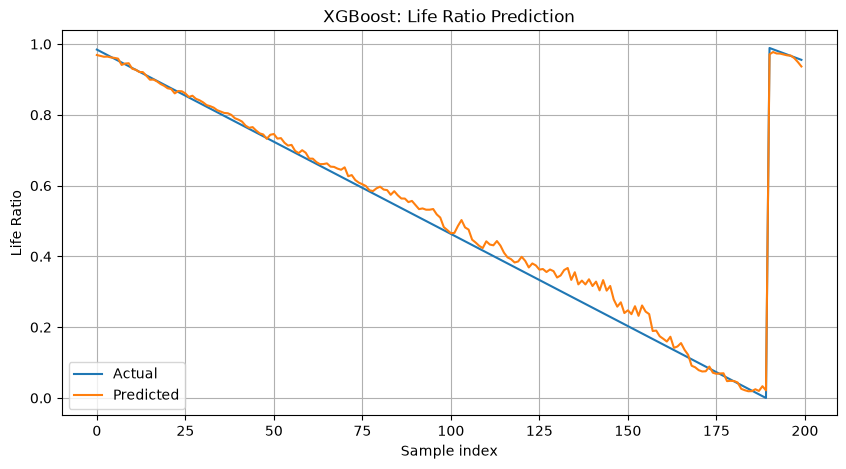

In [36]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("XGBoost: Life Ratio Prediction")
plt.ylabel("Life Ratio")
plt.xlabel("Sample index")
plt.legend()
plt.grid()
plt.show()

## Model comparison table

The validation-set results for the models trained in this notebook (target: `life_ratio`,
bounded in [0, 1]) are summarized below:

| Model | Dataset | RMSE | MAE | R² |
|---|---|---:|---:|---:|
| Random Forest (Optuna-tuned) | Validation | 0.0576 | 0.0434 | 0.9593 |
| XGBoost (Optuna-tuned) | Validation | 0.0561 | 0.0421 | 0.9615 |

These results suggest that the XGBoost model outperformed the Random Forest baseline on
the validation set for this task.

### Interpretable / Explainable predictions using SHAP

In [37]:
import shap

X_sample = X_val.sample(n=10, random_state=42)

explainer = shap.TreeExplainer(best_xg)
shap_values = explainer(X_sample)



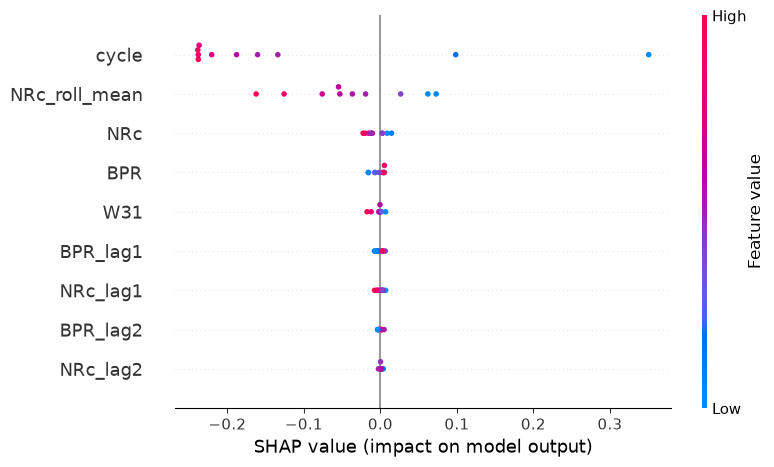

In [38]:
shap.plots.beeswarm(shap_values)

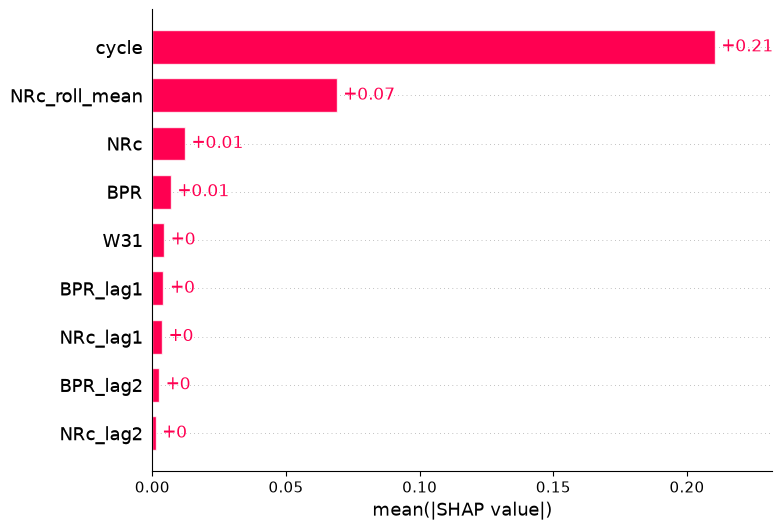

In [39]:
shap.plots.bar(shap_values)

Based on the feature selection scores and SHAP plots, cycle and the NRc-derived features (NRc, its lags, and its rolling mean) contribute the most to life_ratio predictions, followed by BPR and W31 -- consistent with the top-10 features selected above. Also consistent with the RUL notebook.

# Evaluation on test set

In [40]:
import pandas as pd
from src.const import SENSOR_NAMES

# Read raw test data using the same schema as the training data
columns = ["engine_id", "cycle"] + SENSOR_NAMES

# Load the raw test file and the provided RUL values
raw_test = pd.read_csv(
    "../data/raw/test_FD001.txt",
    sep=r"\s+",
    header=None,
    usecols=range(len(columns)),
    names=columns,
    engine="python",
)
raw_rul = pd.read_csv("../data/raw/RUL_FD001.txt", sep=r"\s+", header=None).iloc[:, 0]

# Reconstruct RUL for every observed cycle using the provided terminal RUL values.
# The test set is censored (it doesn't run to failure), so life_ratio can't be
# computed with add_life_ratio() alone -- we need the true total life first.
engine_ids = raw_test["engine_id"].unique()
if len(raw_rul) != len(engine_ids):
    raise ValueError(f"Expected {len(engine_ids)} RUL values, got {len(raw_rul)}")

rul_map = dict(zip(engine_ids, raw_rul.tolist()))
raw_test["rul_at_last_cycle"] = raw_test["engine_id"].map(rul_map)
raw_test["last_cycle"] = raw_test.groupby("engine_id")["cycle"].transform("max")
raw_test["RUL"] = raw_test["rul_at_last_cycle"] + (raw_test["last_cycle"] - raw_test["cycle"])

# Total life = last observed cycle + the RUL still remaining at that cycle
raw_test["total_life"] = raw_test["last_cycle"] + raw_test["rul_at_last_cycle"]
raw_test["life_ratio"] = raw_test["RUL"] / raw_test["total_life"]
raw_test = raw_test.drop(columns=["rul_at_last_cycle", "last_cycle", "RUL", "total_life"])

# Apply the same column drops as training data (skip preprocess(), which assumes
# the dataframe runs to failure -- not true for this censored test set)
raw_test = clean_features(raw_test, cols_to_drop=cols_to_drop)

# Scale using the training-set scaler and create the same engineered features
sensor_cols = get_sensor_columns(raw_test)
raw_test_scaled = raw_test.copy()
raw_test_scaled[sensor_cols] = scaler.transform(raw_test_scaled[sensor_cols])

raw_test_fe = add_time_series_features(raw_test_scaled, sensor_cols)
raw_test_fe = raw_test_fe.dropna().reset_index(drop=True)

# Keep the same feature columns used during model training
raw_test_final = apply_feature_selection(raw_test_fe, selected_features, target="life_ratio")

# Collect processed test data for later evaluation
test_data_processed = [raw_test_final]
test_data_processed = pd.concat(test_data_processed, ignore_index=True)

print("Test preprocessing complete.")
test_data_processed.head()

Test preprocessing complete.


,life_ratio,cycle,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,BPR_lag2,NRc_roll_mean,W31
0,0.979021,3,1,-0.149293,-0.149293,0.752310,-1.278278,1.010825,0.412159,-0.525621,-0.132811
1,0.972028,4,1,-0.977215,-0.149293,-0.050446,-0.149293,0.752310,1.010825,-0.638520,-1.426246
2,0.965035,5,1,-0.864317,-0.977215,0.997219,-0.149293,-0.050446,0.752310,-0.683679,-2.072963
3,0.958042,6,1,-1.052481,-0.864317,0.684280,-0.977215,0.997219,-0.050446,-0.638520,-0.779529
4,0.951049,7,1,-0.864317,-1.052481,0.806734,-0.864317,0.684280,0.997219,-0.781525,-1.426246


In [41]:
train_final.columns

Index(['life_ratio', 'cycle', 'engine_id', 'NRc', 'NRc_lag1', 'BPR',
       'NRc_lag2', 'BPR_lag1', 'BPR_lag2', 'NRc_roll_mean', 'W31'],
      dtype='str')

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare features and target for evaluation
X_test = test_data_processed.drop(columns=["life_ratio", "engine_id"], errors="ignore")
y_test = test_data_processed["life_ratio"]

# Use the trained model from the notebook
if "best_xg" not in globals():
    raise NameError("Train a model first (for example, fit best_xg on X_train/y_train).")

# Predict on the test set
y_pred_test = best_xg.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nTest Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


Test Performance:
RMSE: 0.0669
MAE : 0.0474
R2  : 0.9137


# Error Analysis

Mean test residual (Actual - Predicted): 0.010239347608192742


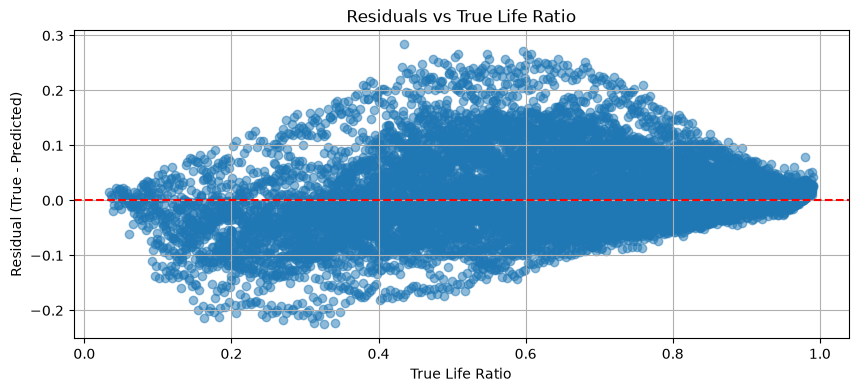

In [43]:
residuals = y_test - y_pred_test
print("Mean test residual (Actual - Predicted):", residuals.mean())

plt.figure(figsize=(10, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("True Life Ratio")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals vs True Life Ratio")
plt.grid(True)
plt.show()

On the held-out test set, the mean residual is about +0.010 (Actual - Predicted), a small underprediction on average. Unlike the raw-RUL version of this notebook, the bias here is close to zero relative to the [0, 1] scale of life_ratio.

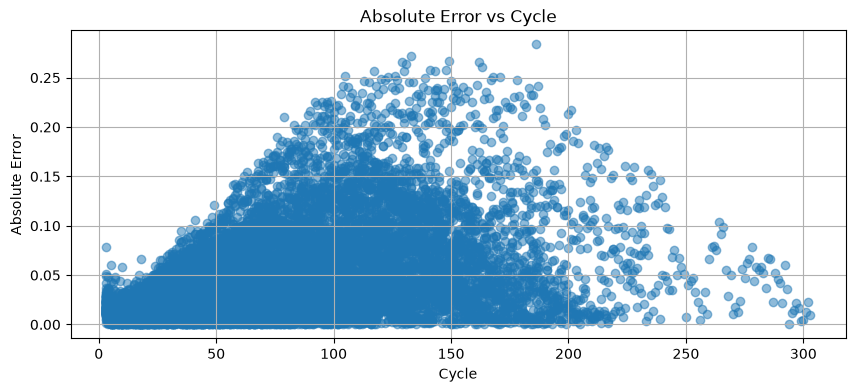

In [44]:
### Error by cycle
plt.figure(figsize=(10, 4))
plt.scatter(test_data_processed["cycle"], np.abs(residuals), alpha=0.5)
plt.xlabel("Cycle")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Cycle")
plt.grid(True)
plt.show()


Error is lower near failure, more accurate closer to failure

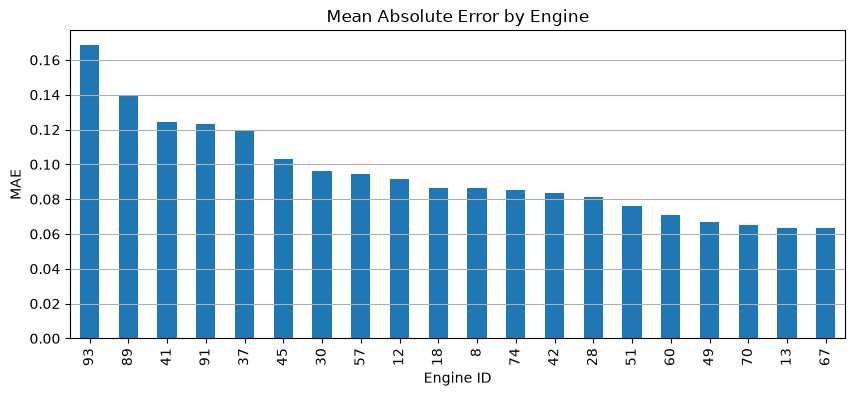

In [45]:
### Error by engine
engine_errors = pd.DataFrame({
    "engine_id": test_data_processed["engine_id"],
    "abs_error": np.abs(residuals)
}).groupby("engine_id")["abs_error"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
engine_errors.head(20).plot(kind="bar")
plt.title("Mean Absolute Error by Engine")
plt.ylabel("MAE")
plt.xlabel("Engine ID")
plt.grid(axis="y")
plt.show()

Engine 93 has the highest errors

# Classification Evaluation via binning


When life_ratio is below 0.1 (10% of life remaining), we treat the engine as being in a near-failure state and flag it for maintenance attention. This is often more actionable from a business perspective than reporting a raw life_ratio number, because it supports clear operational decisions such as scheduling inspection, maintenance, or replacement.

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

# Note: threshold should not be tuned using test set
def binary_evaluation(threshold=0.1, pred_offset=0.0):
    # Convert continuous life_ratio into a binary class: 1 = near failure, 0 = not near failure
    y_true_bin = (y_test <= threshold).astype(int)
    y_pred_bin = (y_pred_test <= threshold + pred_offset).astype(int)

    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    print("Binary Classification Metrics")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_bin, y_pred_bin, target_names=["Not Near Failure", "Near Failure"]))

    # Optional: plot confusion matrix
    import seaborn as sns
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Near Failure", "Near Failure"], yticklabels=["Not Near Failure", "Near Failure"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix for Near-Failure Classification")
    plt.show()

Binary Classification Metrics
Accuracy : 0.9949
Precision: 0.7217
Recall   : 0.7094
F1-score : 0.7155

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       1.00      1.00      1.00     12779
    Near Failure       0.72      0.71      0.72       117

        accuracy                           0.99     12896
       macro avg       0.86      0.85      0.86     12896
    weighted avg       0.99      0.99      0.99     12896



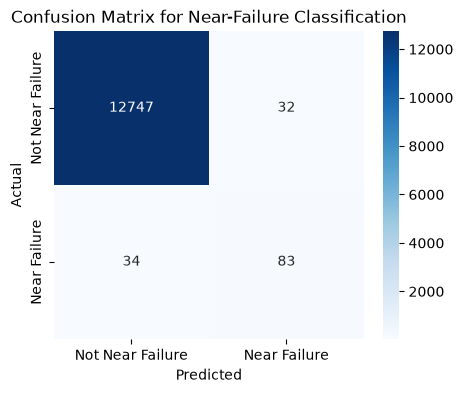

In [47]:
binary_evaluation()

Binary Classification Metrics
Accuracy : 0.9899
Precision: 0.4716
Recall   : 0.9231
F1-score : 0.6243

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       1.00      0.99      0.99     12779
    Near Failure       0.47      0.92      0.62       117

        accuracy                           0.99     12896
       macro avg       0.74      0.96      0.81     12896
    weighted avg       0.99      0.99      0.99     12896



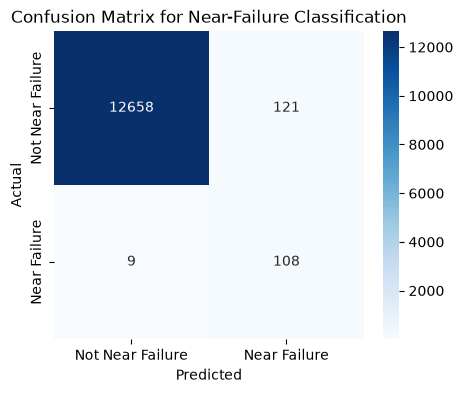

In [48]:
binary_evaluation(pred_offset=0.05)

Because life_ratio is bounded in [0, 1], a prediction offset here is a small ratio
(e.g. 0.05) rather than a cycle count. As before, increasing the offset improves recall
at the cost of precision, letting the business choose the tradeoff between catching more
at-risk engines and tolerating more false alarms.

Example:

Model with offset=0:
- precision = 0.72
- recall = 0.71

Model with offset=0.05:
- precision = 0.47
- recall = 0.92

# Verdict: Life ratio vs RUL

Life ratio often produces better RMSE, R², and classification performance in CMAPSS because it normalizes the degradation trajectory into a bounded and monotonic signal. This makes the learning problem easier by reducing target variance and aligning all engines onto a common [0, 1] health scale. However, this improvement does not necessarily reflect better physical prediction of remaining useful life, since life ratio is defined using failure-cycle information, it can be viewed as a reparameterized target that differs from the standard RUL formulation.

## Future work for model improvements

Several next steps could further improve the model and make the results more robust:

- Add a baseline model comparison table, including simple baselines and more advanced models, to better quantify the gain from the current approach.
- Run an ablation study for lag and rolling features to measure how much each feature group contributes to predictive performance.
- Combine multiple datasets or operating conditions to improve generalization and reduce overfitting to a single fleet or regime.
